# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import save_parquet, load_parquet
from datetime import datetime
import os
import sys
import shap
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    fit_gapfill_ts,
    build_df_for_parcel,
    apply_gapfill_ts,
    plot_gapfill_dashboard,
    merge_gapfill_results
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'FN2O'
RAND_ERR_COL = "FN2O_RANDUNC_HF"  # EddyPro random uncertainty col
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
PARCEL_CERTAIN = True
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True
SHAP_CHECK = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')

# Make a copy of the original data for later use
maindf = data_main.copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data_main = data_main[data_main['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.089 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 13776 of 13776 records (2024-08-22 00:15:00 to 2025-06-04 23:45:00, timestamp=middle)

Keeping only data when we are highly confident on the parcel attribution


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FN2O_RANDUNC_HF,SW_IN_POT,prec,ta,...,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,can_height,cropN,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,4.791627,0.475098,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.461859,0.0,0.000,11.276667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,0
2024-08-22 00:45:00,4.565958,0.662601,0.365031,0.365031,NaN,NaN,NaN,NaN,A,certain,0.0,0.779504,0.0,0.000,11.043333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,1
2024-08-22 01:45:00,4.323735,0.851883,1.399927,NaN,NaN,1.399927,NaN,NaN,A,certain,0.0,0.457078,0.0,0.000,10.720000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,3
2024-08-22 02:15:00,4.323735,0.868263,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,0.560318,0.0,0.000,10.820000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,4
2024-08-22 02:45:00,4.494796,0.677546,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,0.554503,0.0,0.000,10.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,-0.970199,0.524032,0.524032,0.524032,0.524032,0.524032,0.524032,B,certain,1.0,0.226180,0.0,0.017,15.693333,...,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515,39.079782,NaN,13771
2025-06-04 22:15:00,9.416519,0.146401,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.249031,0.0,0.034,15.516667,...,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001,39.111514,NaN,13772
2025-06-04 22:45:00,10.095010,-0.495217,-0.069384,-0.069384,-0.069384,-0.069384,-0.069384,-0.069384,B,certain,1.0,0.279950,0.0,0.425,15.660000,...,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494,39.143246,NaN,13773


# SELECT FEATURES

In [4]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
#     'SW_IN_POT',
#     'ppfd',
#     'timesince_soil_preparation',
#     'timesince_sowing',
#     'n_decay_timed',
#     'ts_0.3_gfXG_roll3hmean'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

selected_features


The treatment variable (trt) is included in the feature set


['n_decay_linear',
 'n_decay_exponential',
 'n_decay_lognormal',
 'timesince_sowing',
 'wfps_0.05_gfXG_lag3h',
 'wfps_0.05_gfXG_lag9h',
 'wfps_0.15_gfXG_lag9h',
 'wfps_0.05_gfXG_lag3h_roll9hmean',
 'wfps_0.05_gfXG_lag6h_roll6hmean',
 'wfps_0.15_gfXG_lag3h_roll9hmean',
 'wfps_0.15_gfXG_lag6h_roll6hmean',
 'wfps_0.15_gfXG_lag9h_roll3hmean',
 'id',
 'trt']

# SELECT MODEL

In [5]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1)
    else:
        return XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.8189785227596447, 'gamma': 0.2254552237080522, 'learning_rate': 0.09604712784032732, 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 180, 'subsample': 0.9798082494630569}


# GAP-FILLING

## CUT-16

In [6]:
USTAR_CUT = 'CUT_16'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FN2O_L3.3_CUT_16_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 24.0265; raw baseline 29.1028)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.102
  Coverage: 594/4802 rows never held out (12.4%); mean times held out 2.01


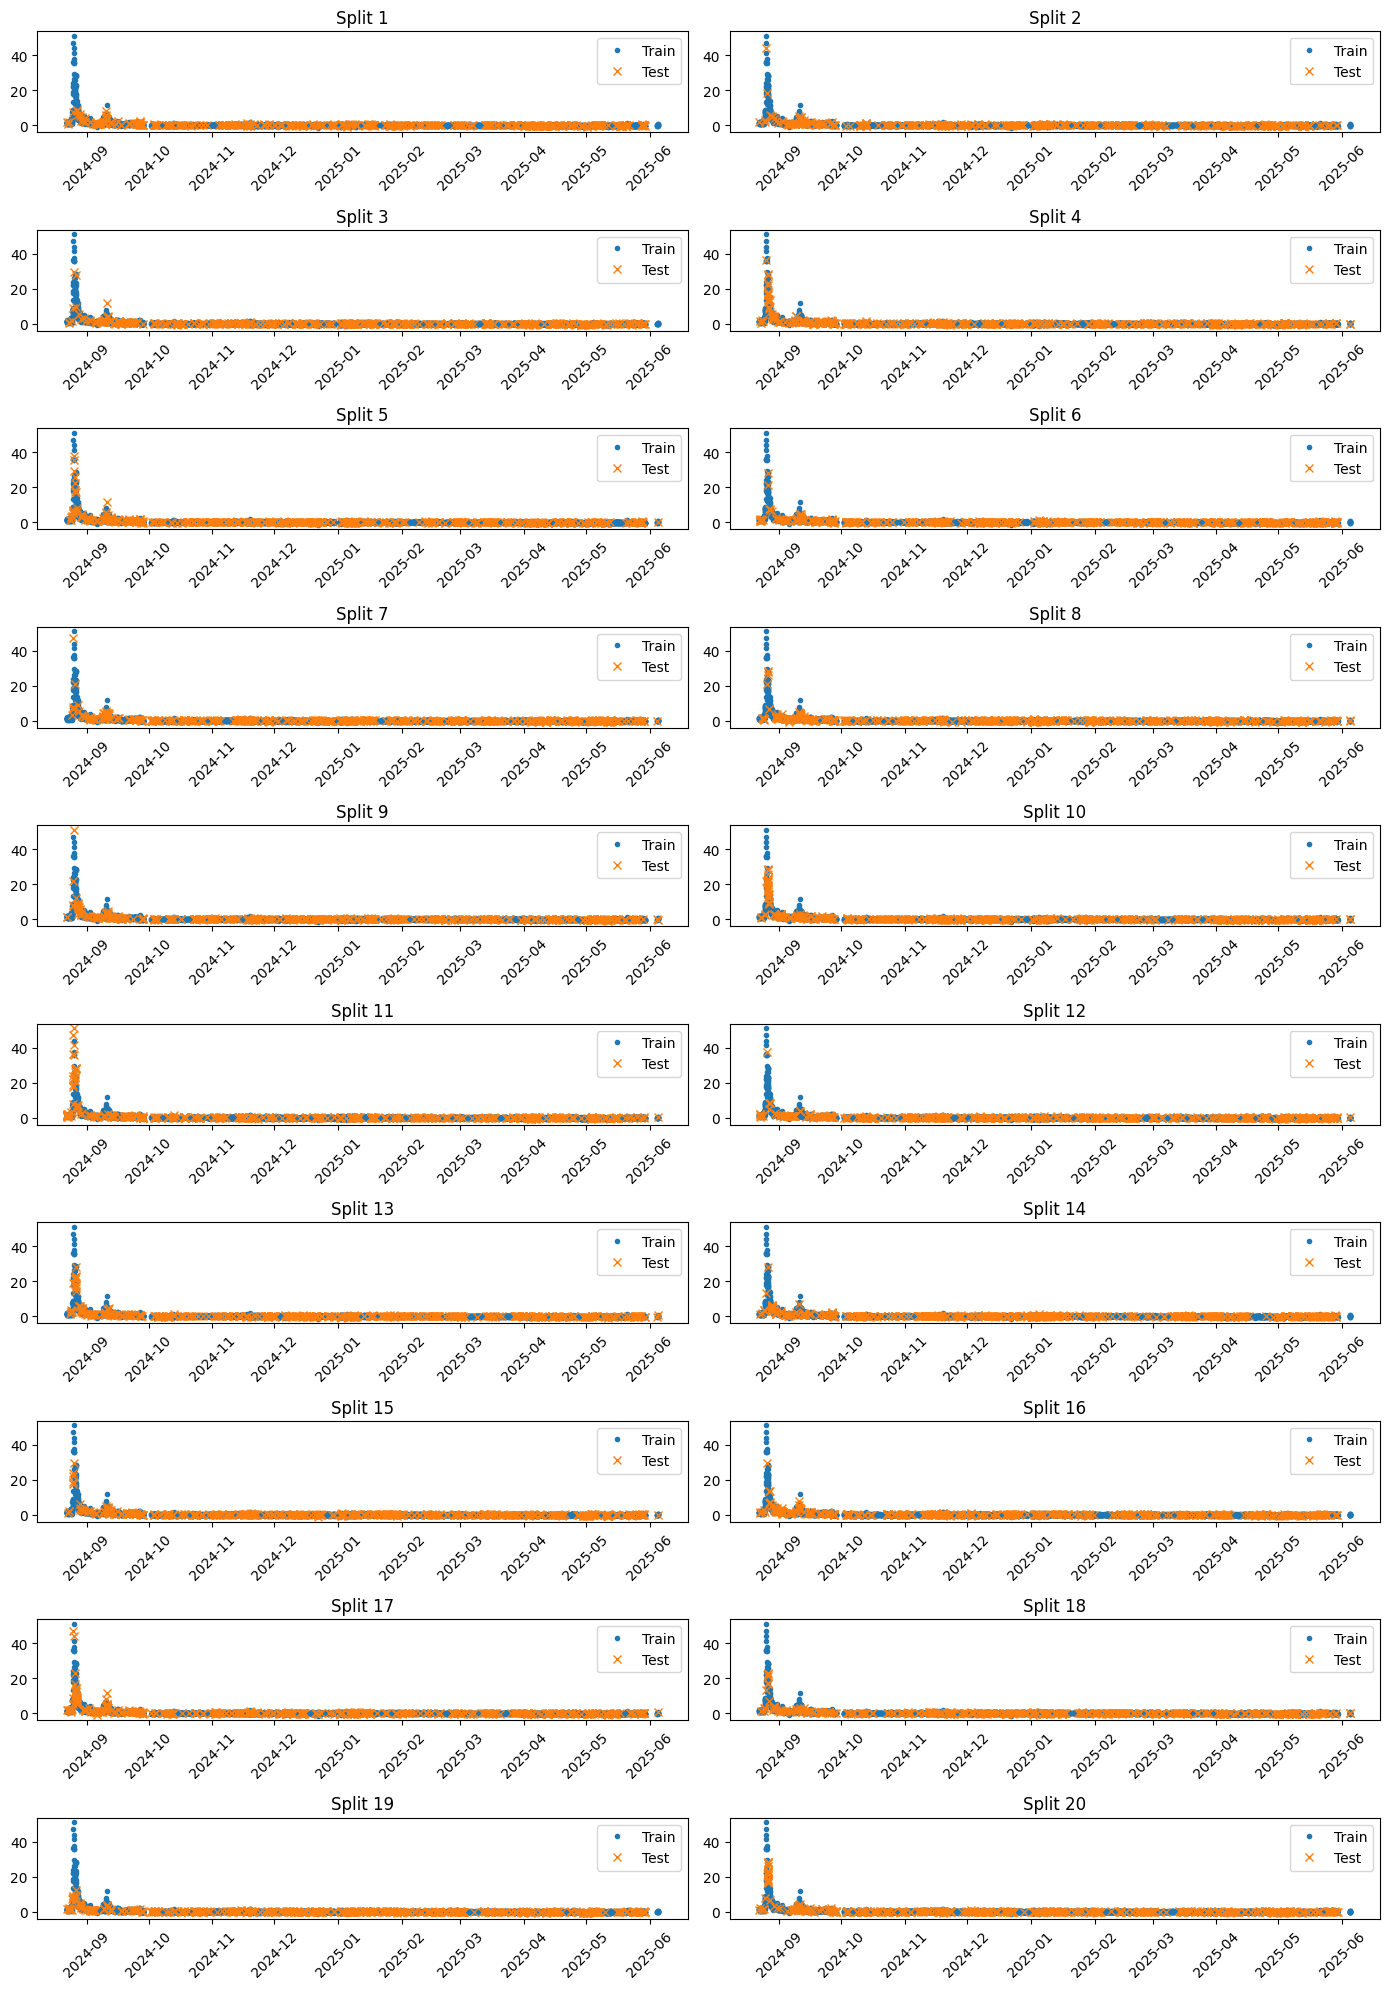

Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_16_QCF0
  RMSE:   0.7062
  MAE:    0.2683
  R2:     0.9332
----------------------------------------
Fitting final model on full training set...


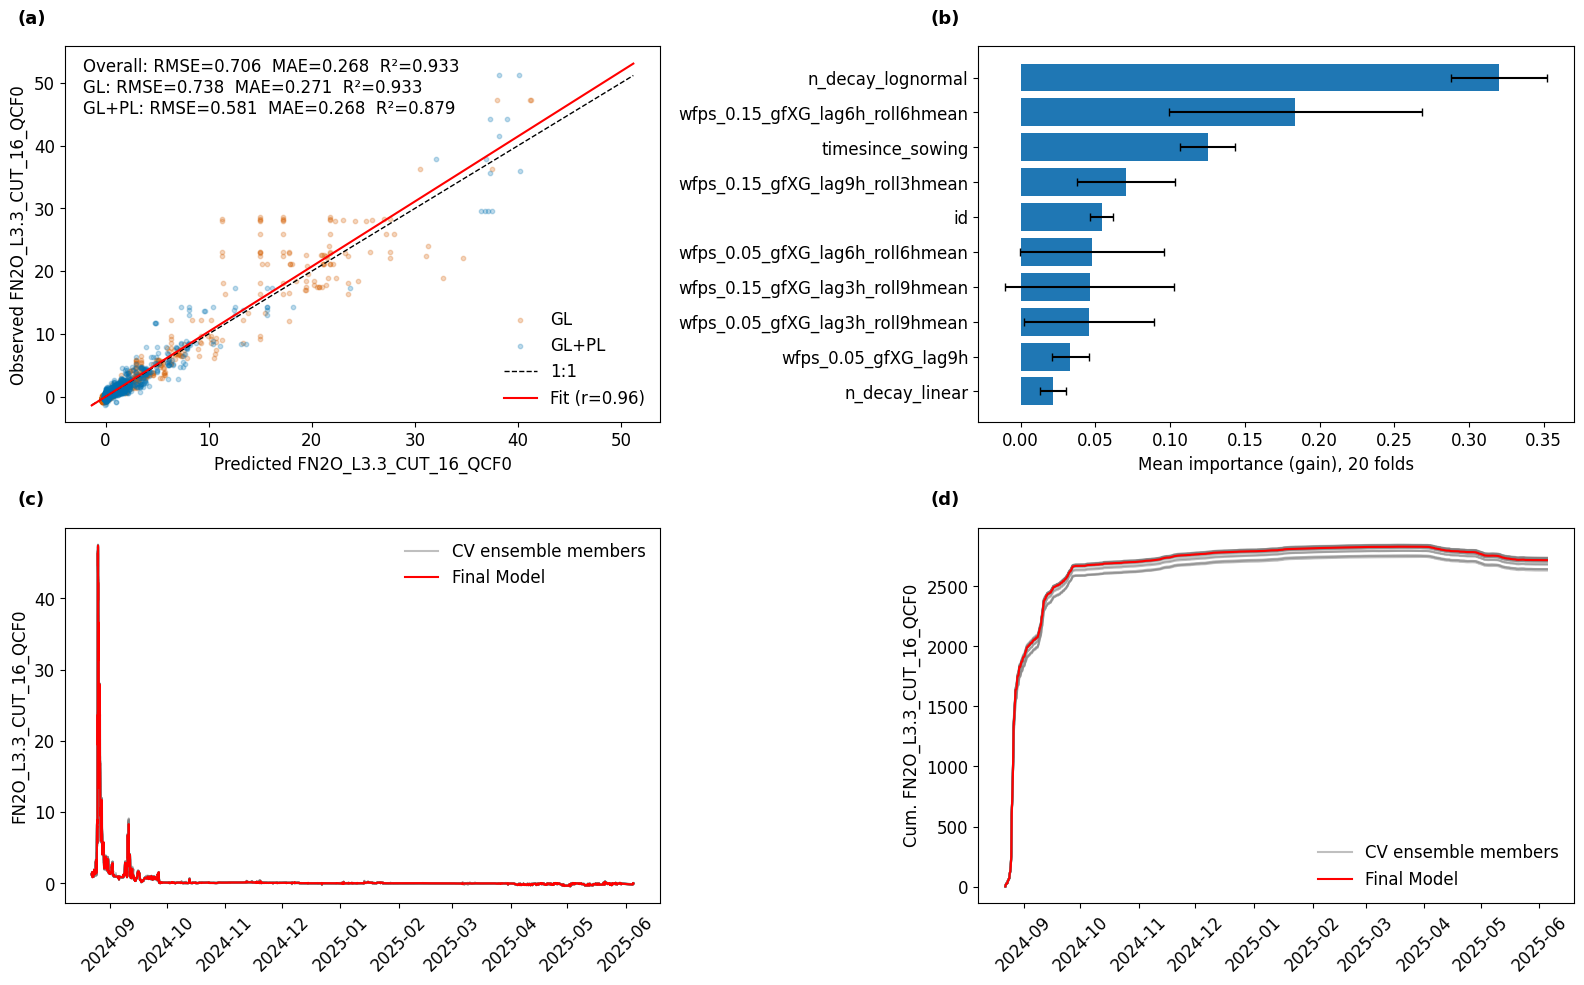

Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 29.0099; raw baseline 32.0799)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.099-0.104
  Coverage: 609/5462 rows never held out (11.1%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_16_QCF0
  RMSE:   0.6148
  MAE:    0.2470
  R2:     0.9090
----------------------------------------
Fitting final model on full training set...


Finished training. Ensemble size (folds): 20


In [7]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,
    undersample=UNDERSAMPLE
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,
        undersample=UNDERSAMPLE,
        plot=False
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")


### GAPFILLING

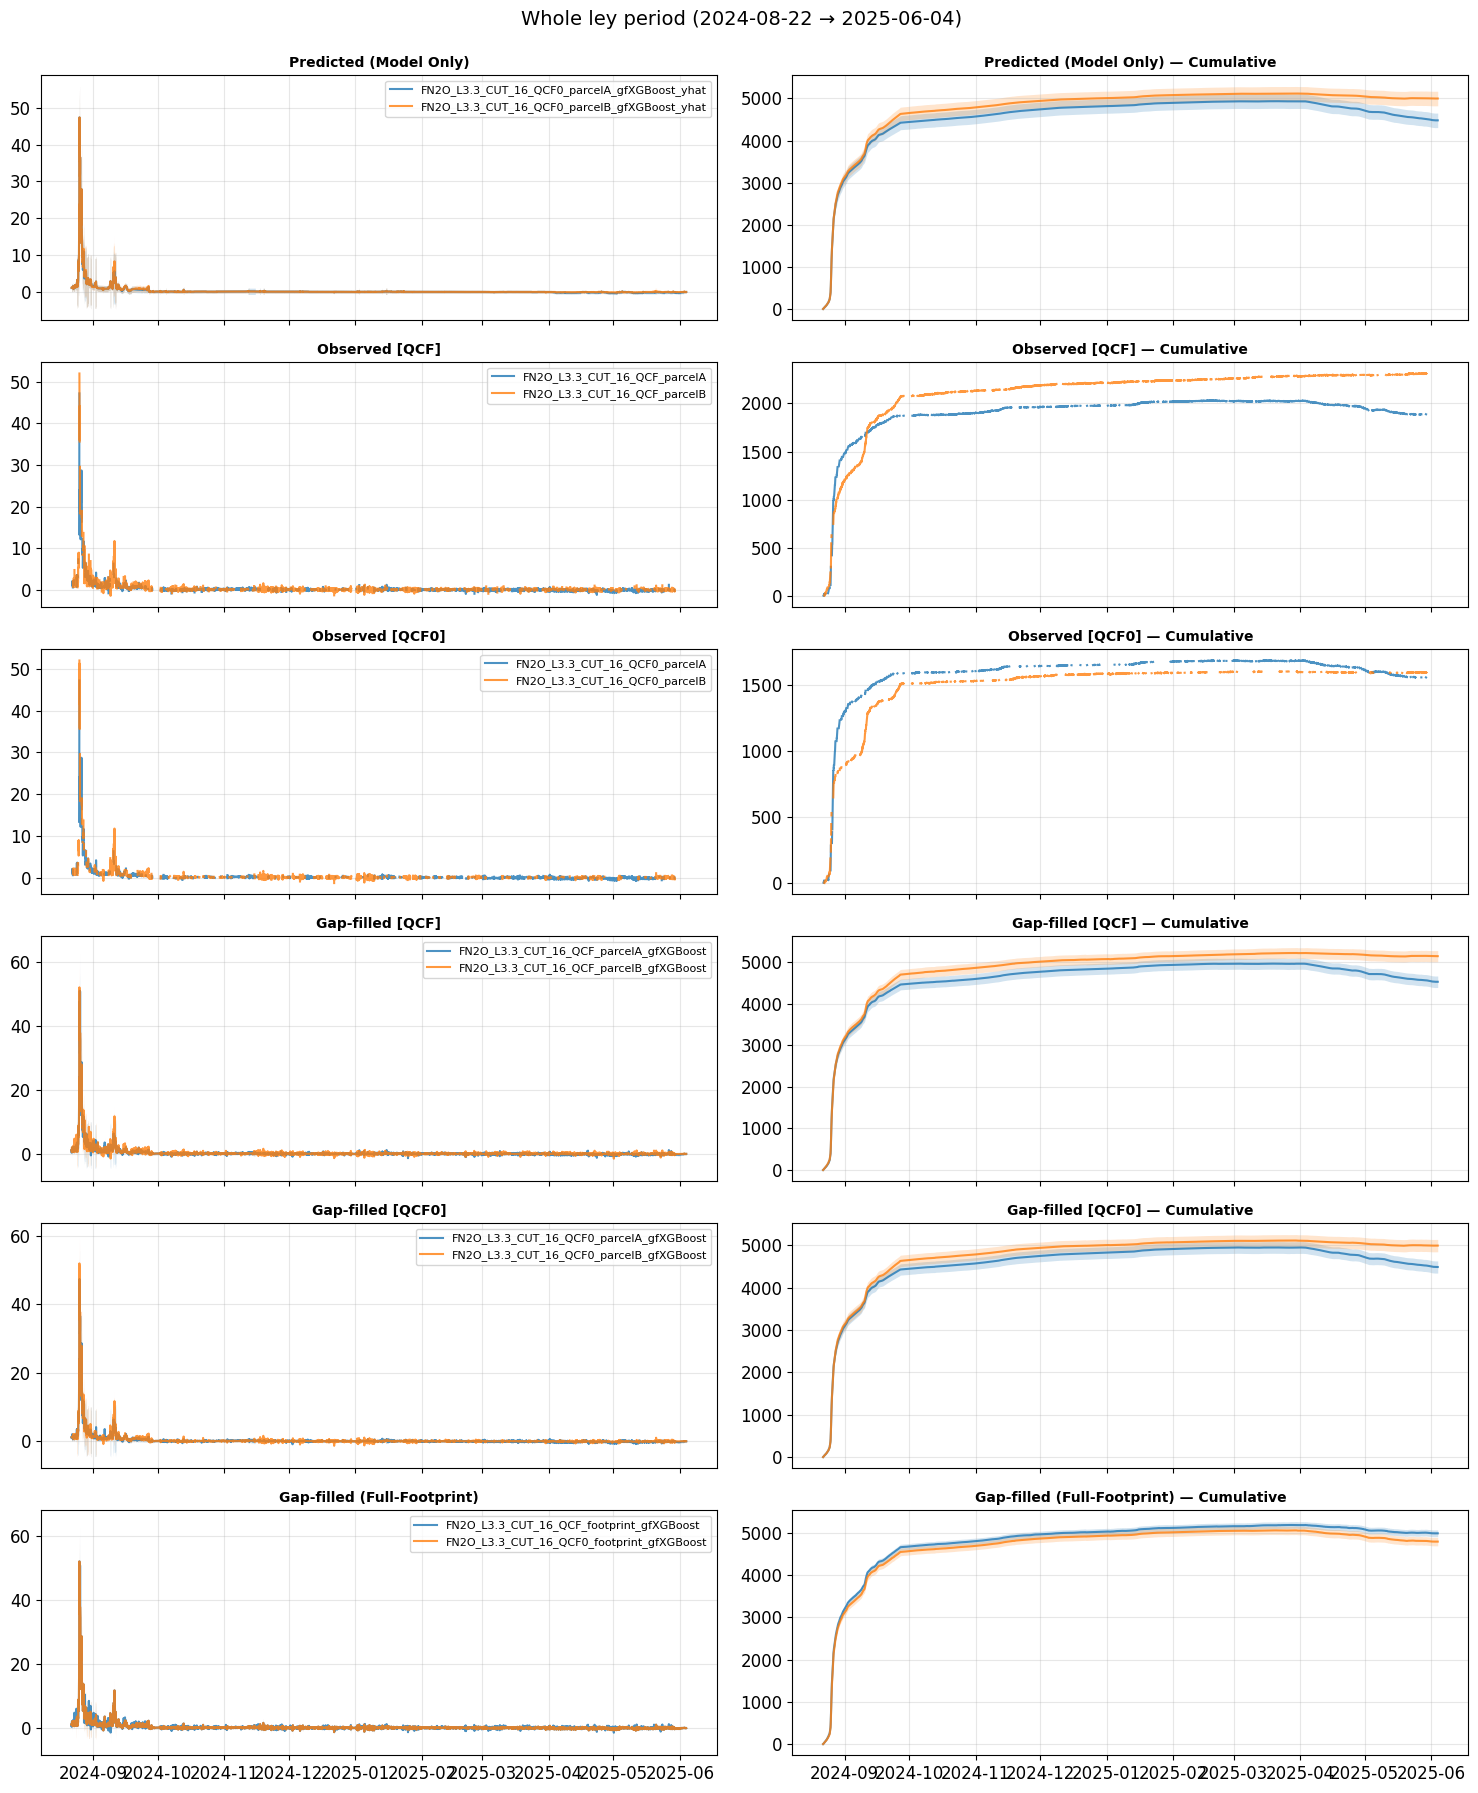

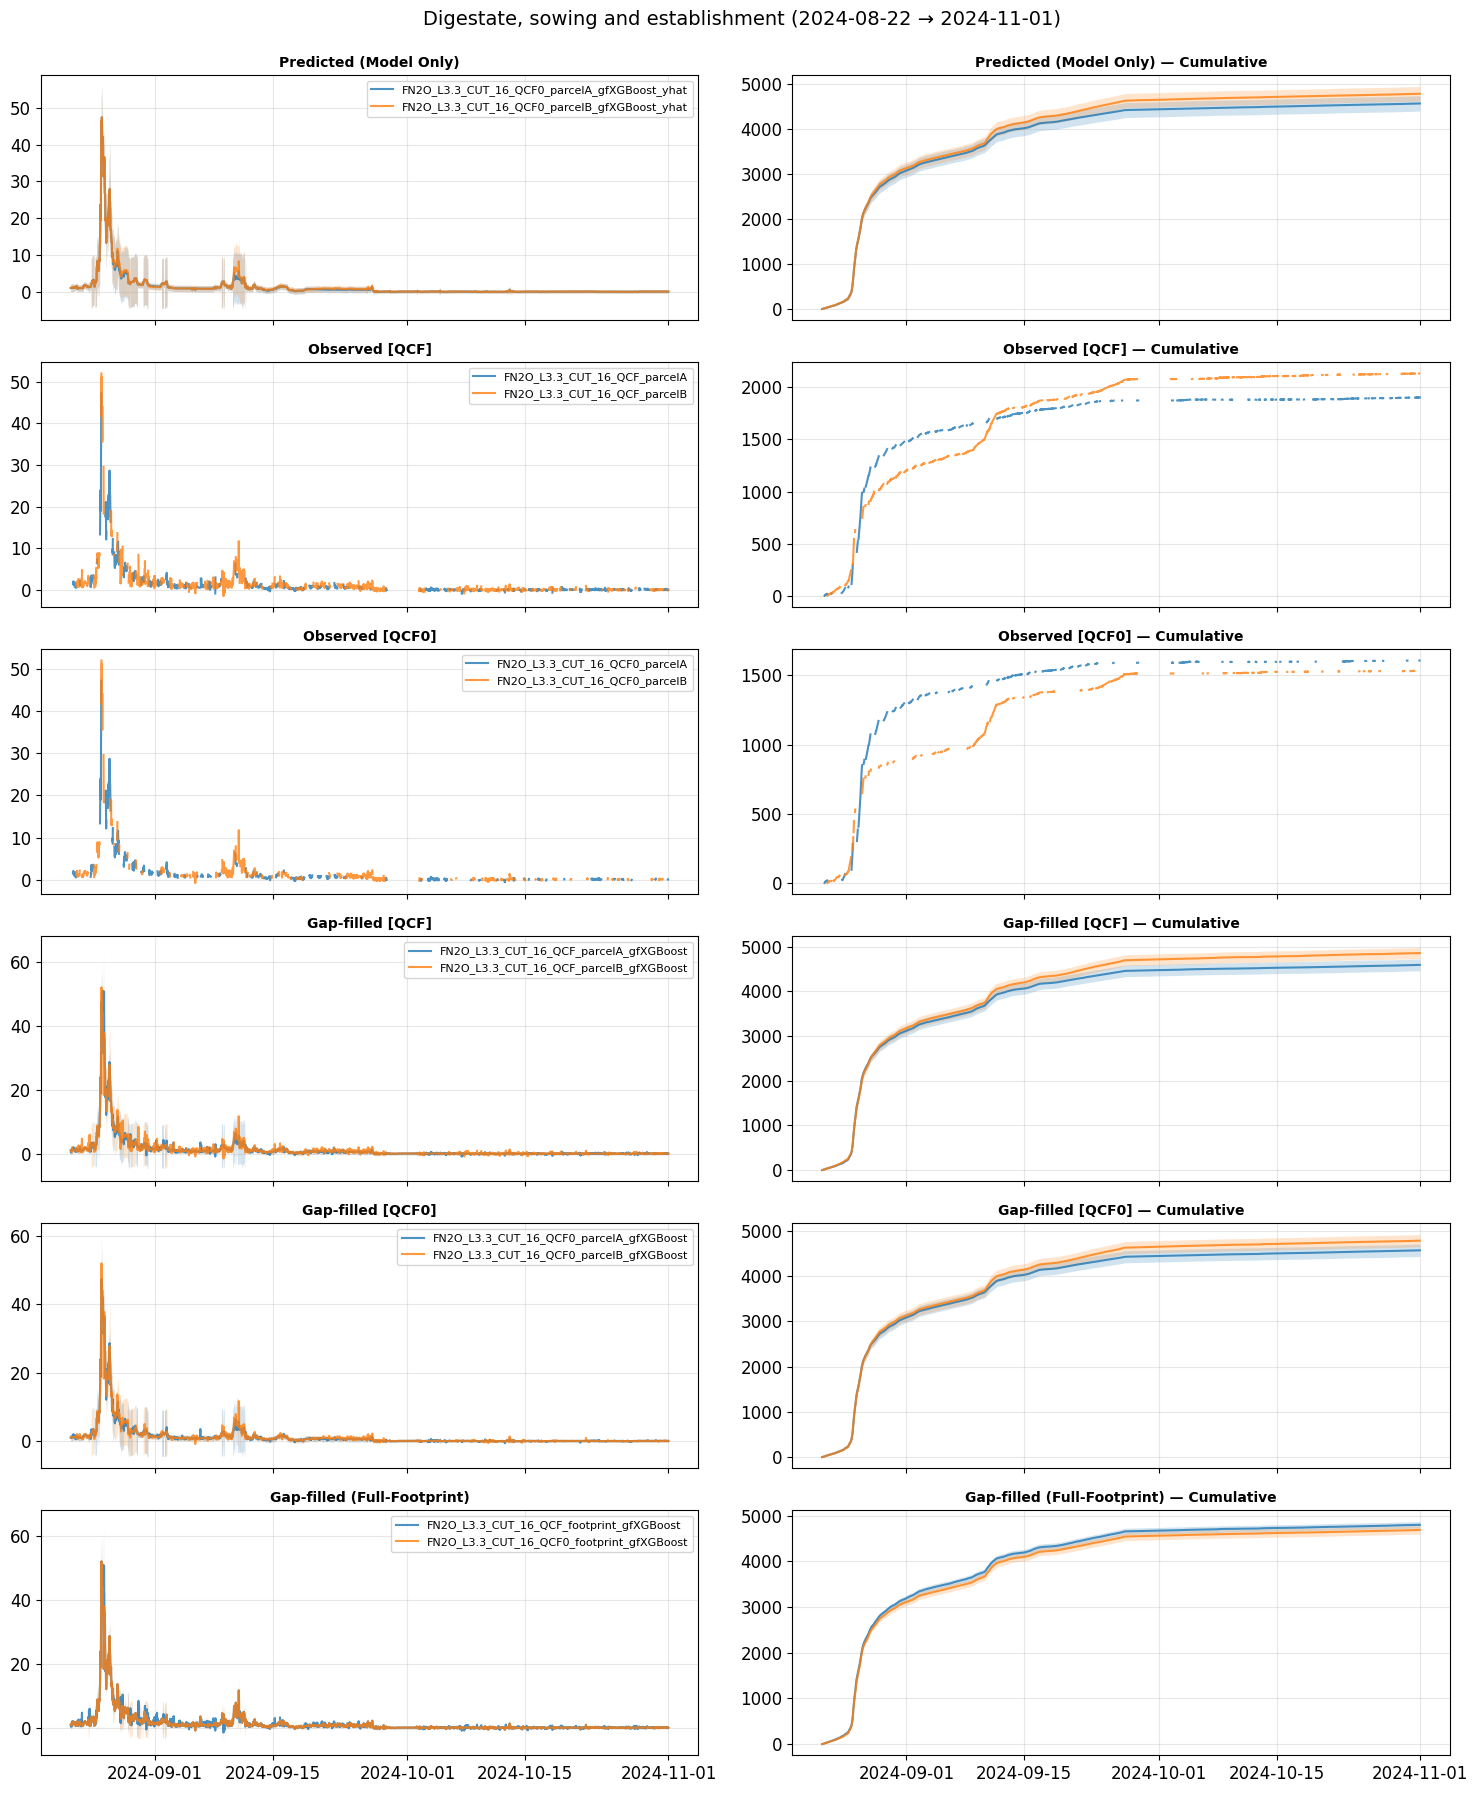

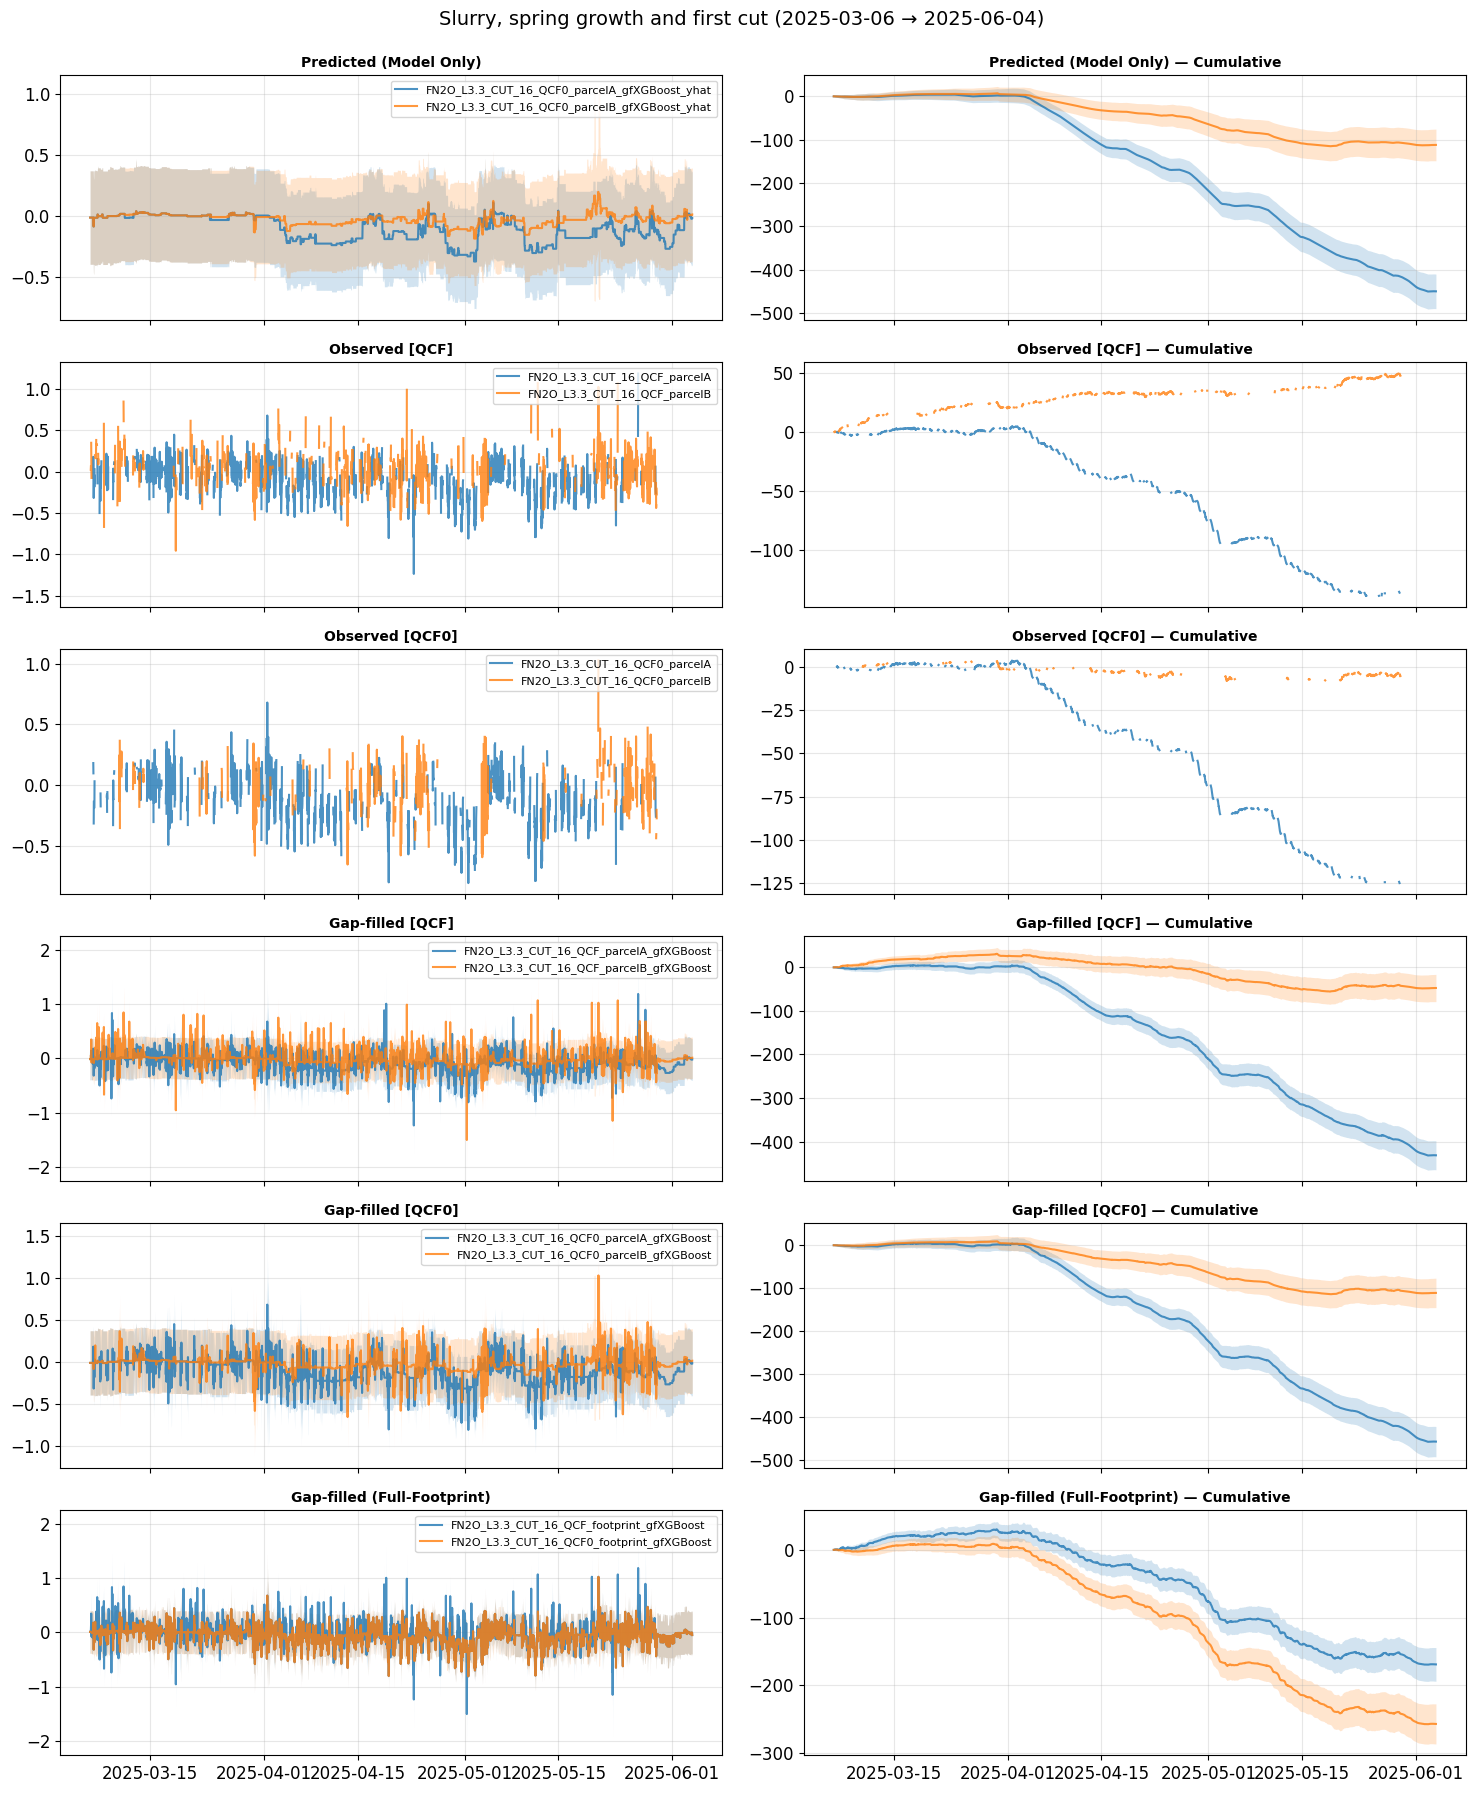

In [8]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2024-08-22", "2025-06-04", "Whole ley period"),
    ("2024-08-22", "2024-11-01", "Digestate, sowing and establishment"),
    ("2025-03-06", "2025-06-04", "Slurry, spring growth and first cut")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT16
df_CUT16 = df_final.copy()


## CUT-50

In [9]:
USTAR_CUT = 'CUT_50'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FN2O_L3.3_CUT_50_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 20.0273; raw baseline 23.4998)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.099-0.101
  Coverage: 569/4665 rows never held out (12.2%); mean times held out 2.00


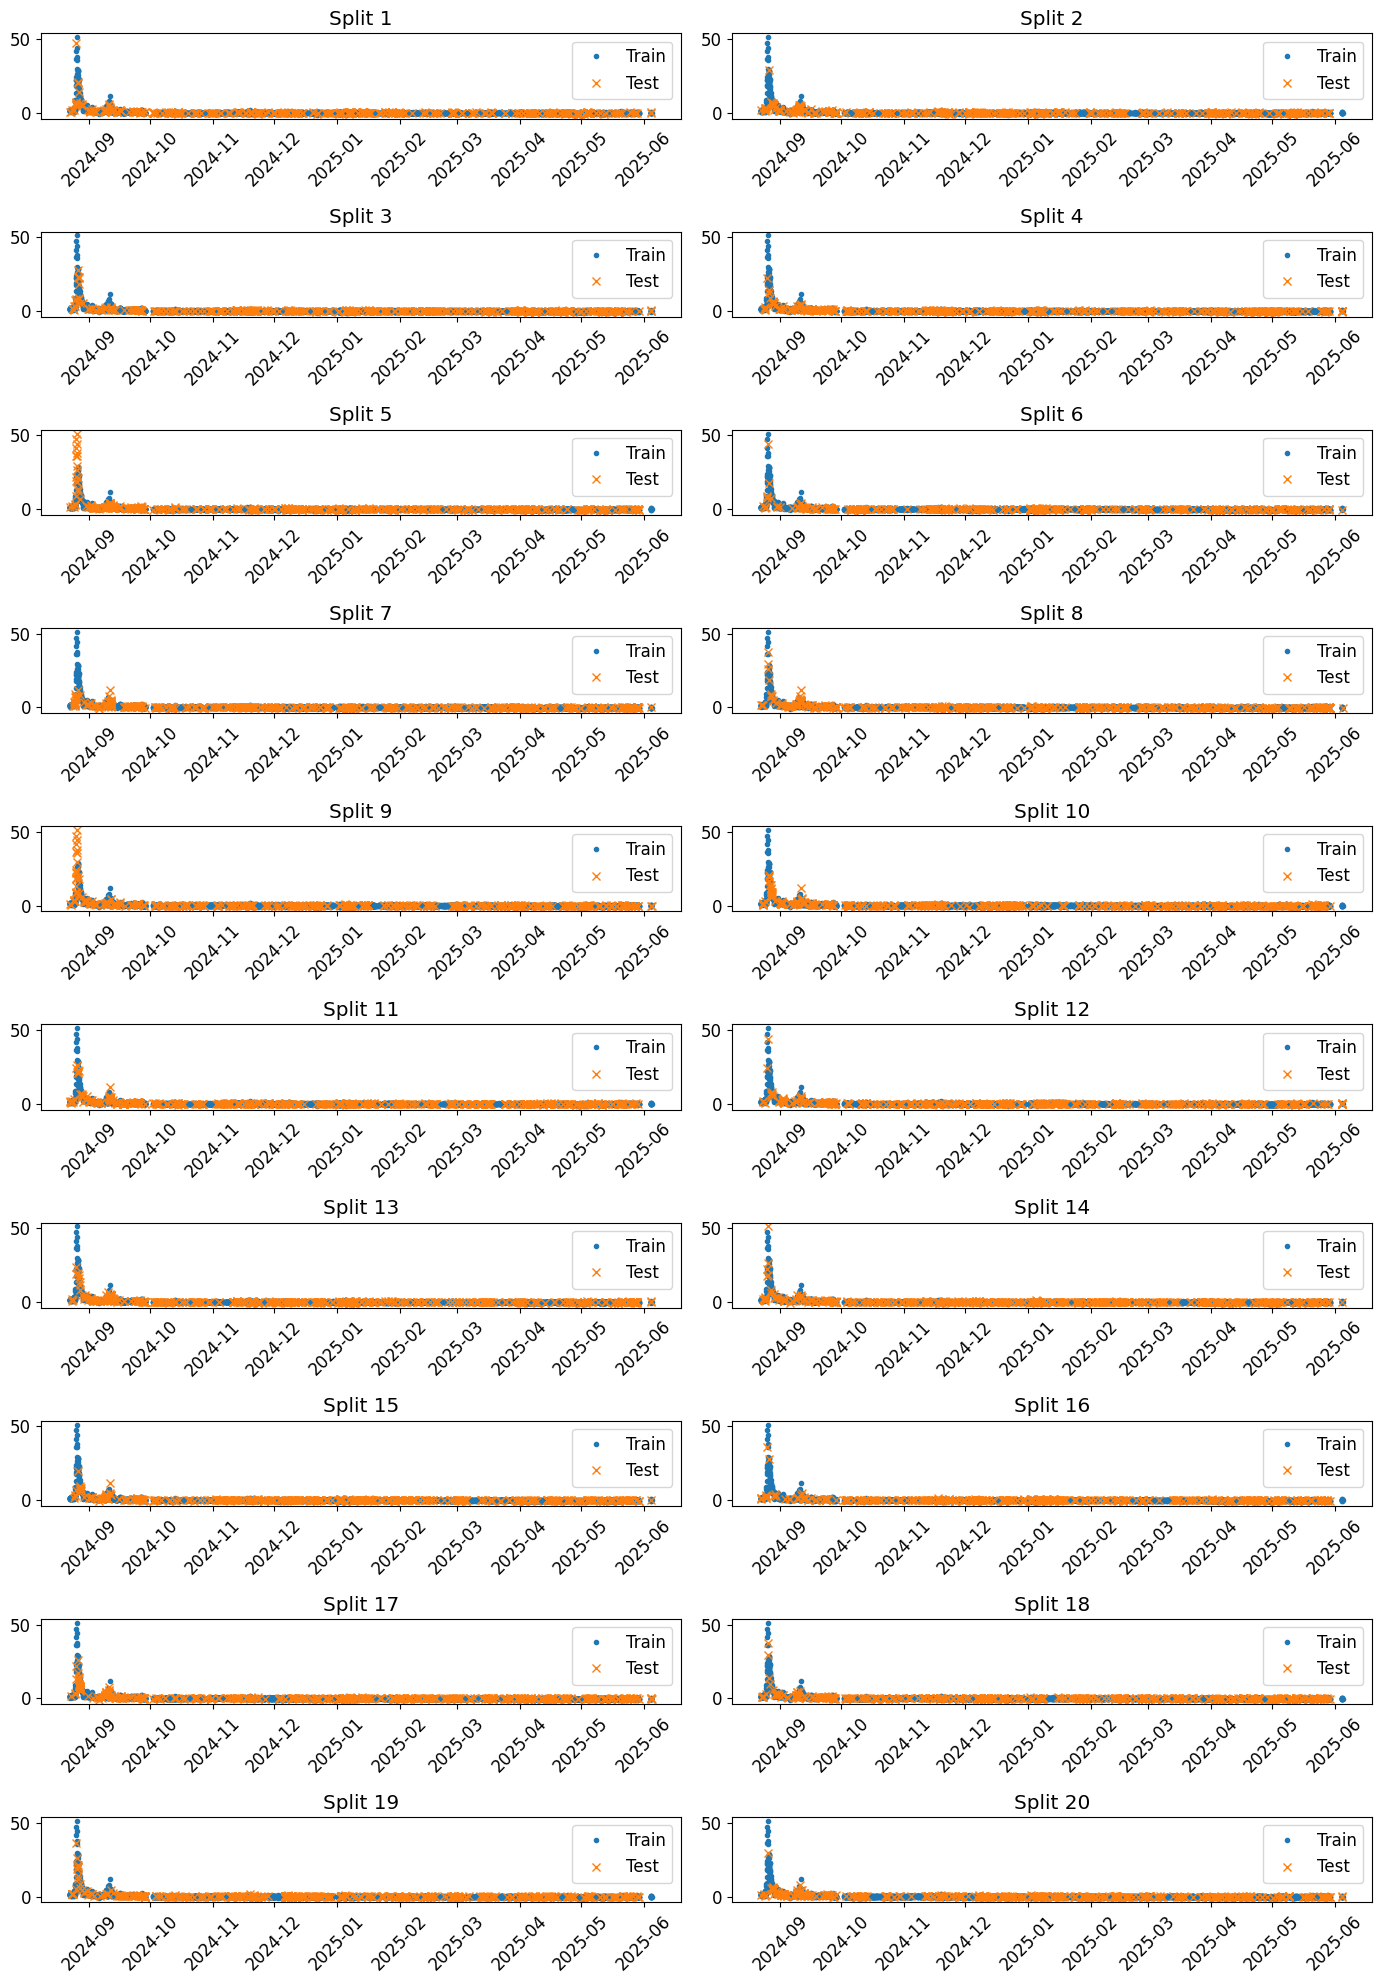

Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_50_QCF0
  RMSE:   0.8046
  MAE:    0.2874
  R2:     0.9105
----------------------------------------
Fitting final model on full training set...


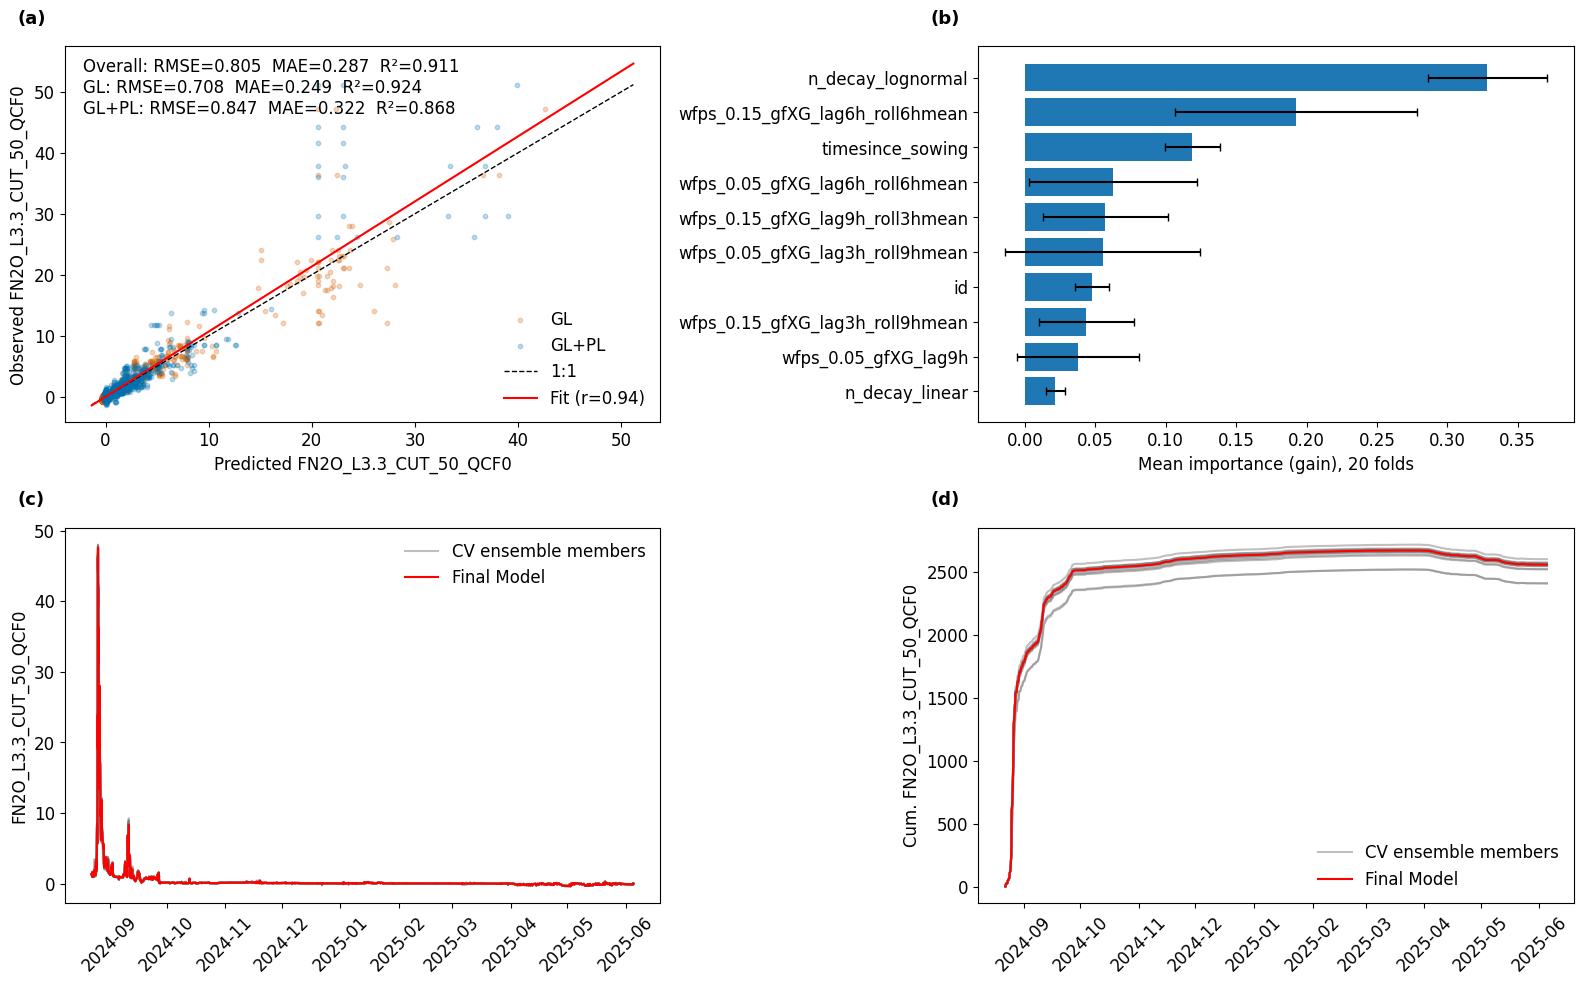

Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 25.6617; raw baseline 30.6735)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.102
  Coverage: 630/5289 rows never held out (11.9%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_50_QCF0
  RMSE:   0.6271
  MAE:    0.2442
  R2:     0.9263
----------------------------------------
Fitting final model on full training set...


Finished training. Ensemble size (folds): 20


In [10]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,
    undersample=UNDERSAMPLE,
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,
        undersample=UNDERSAMPLE,
        plot=False
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")


### GAPFILLING

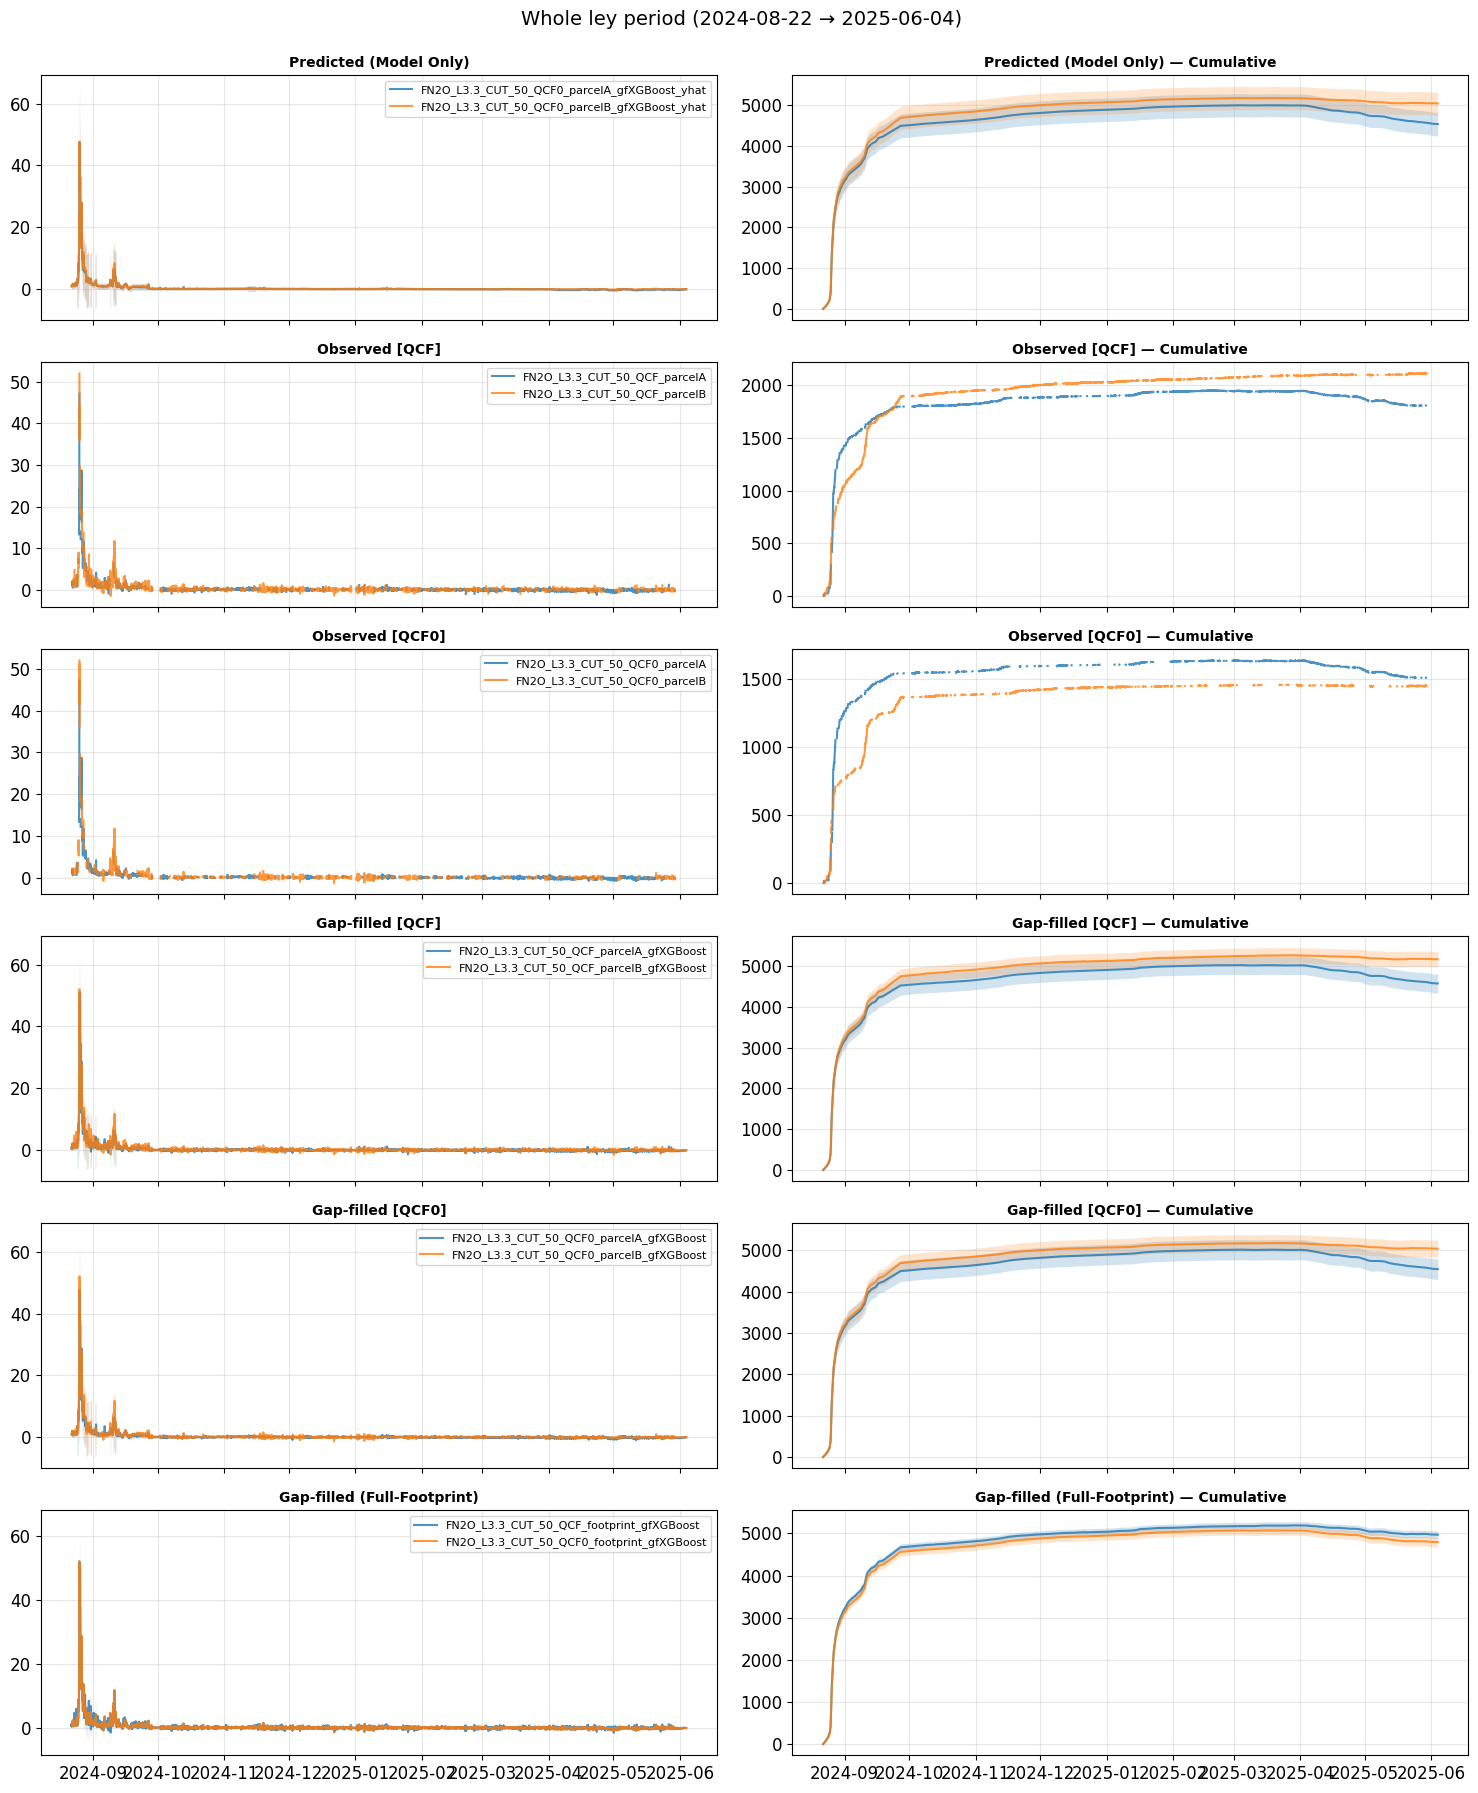

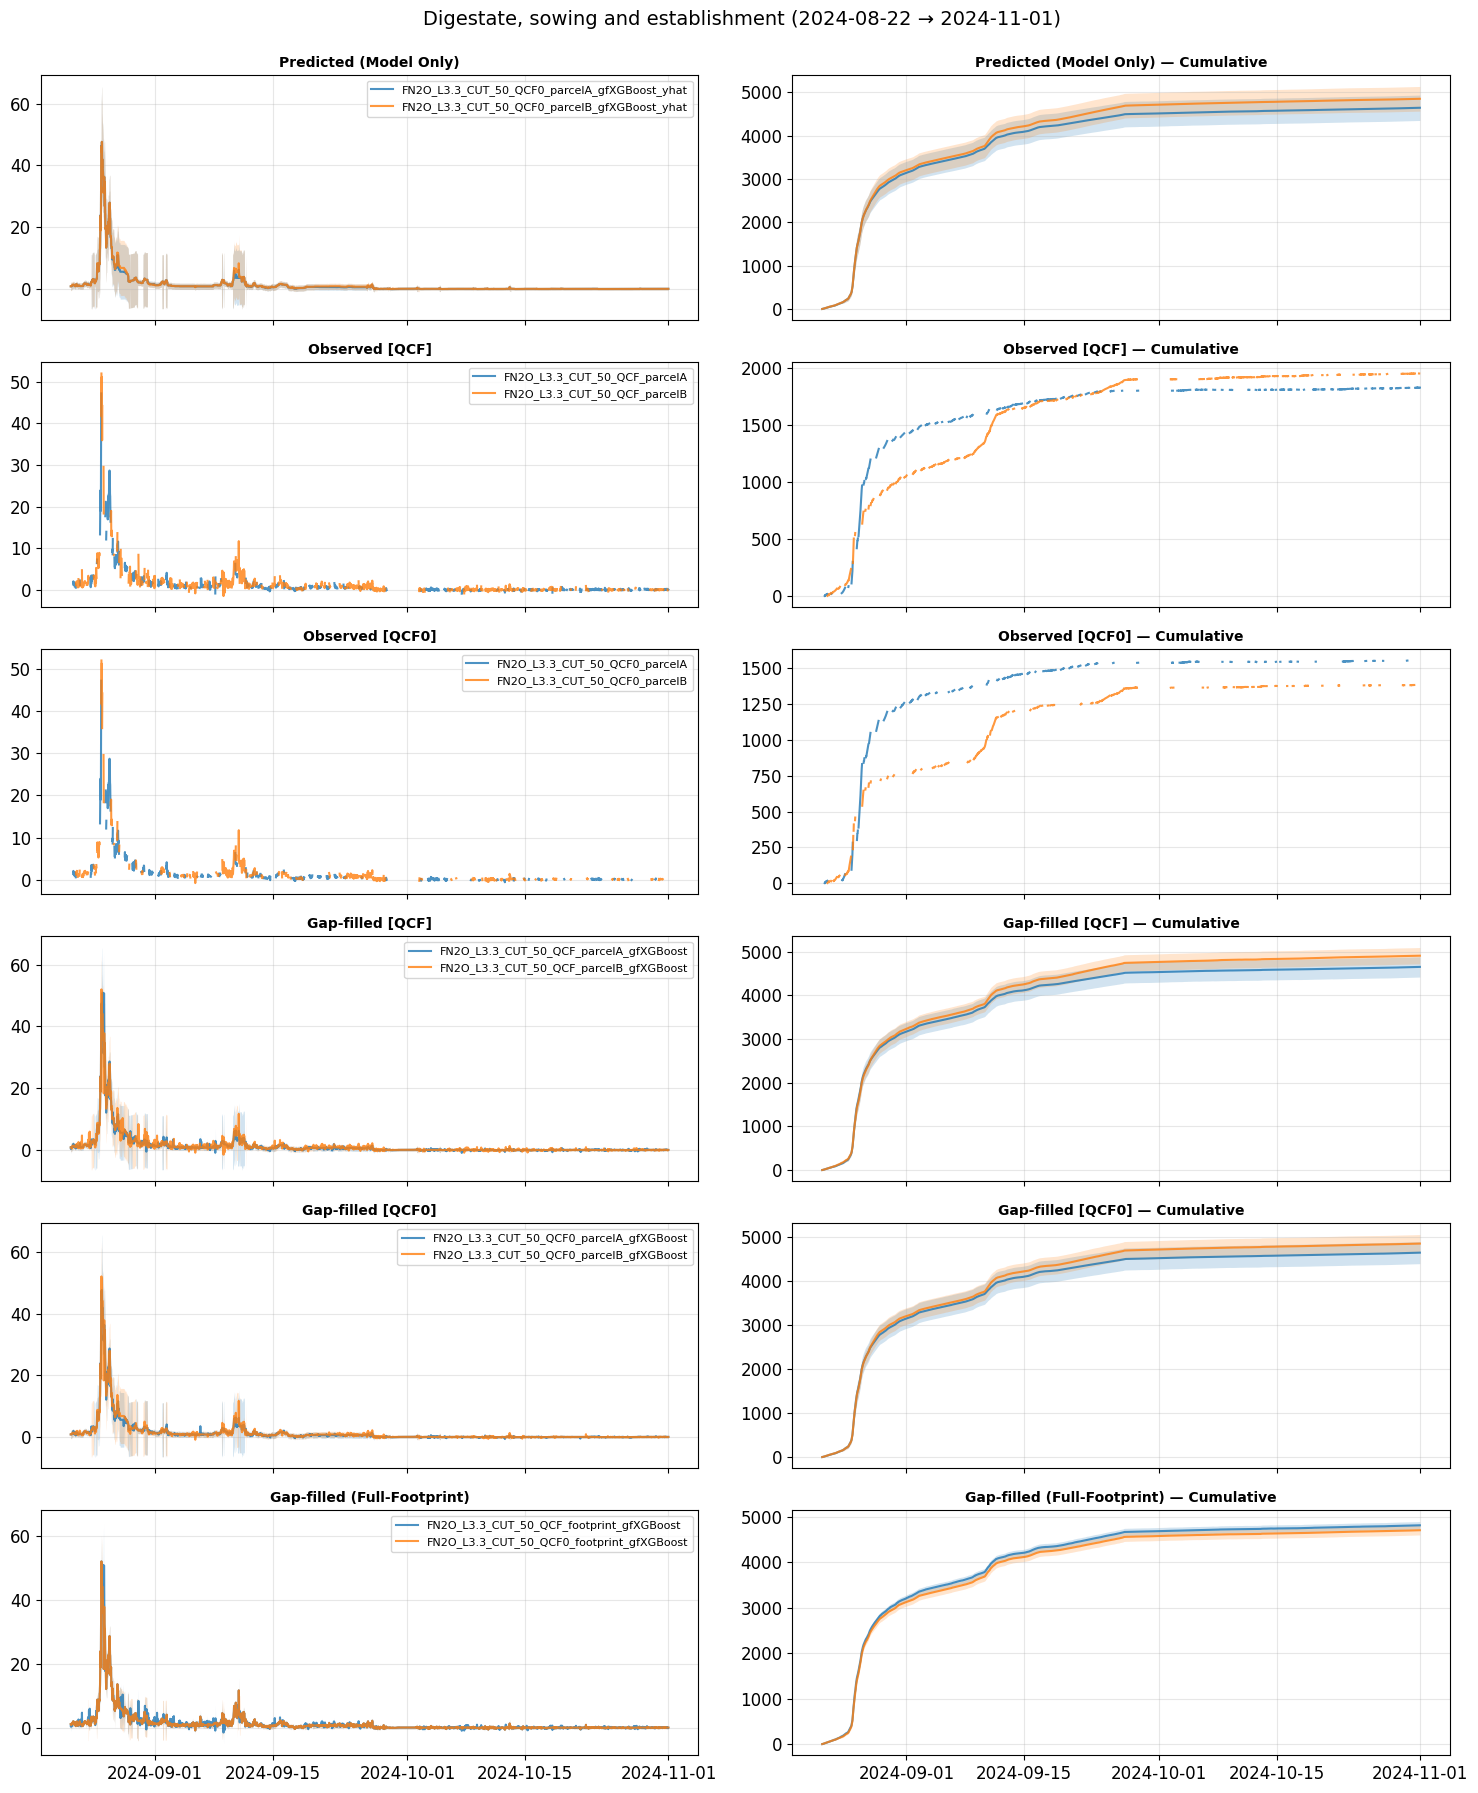

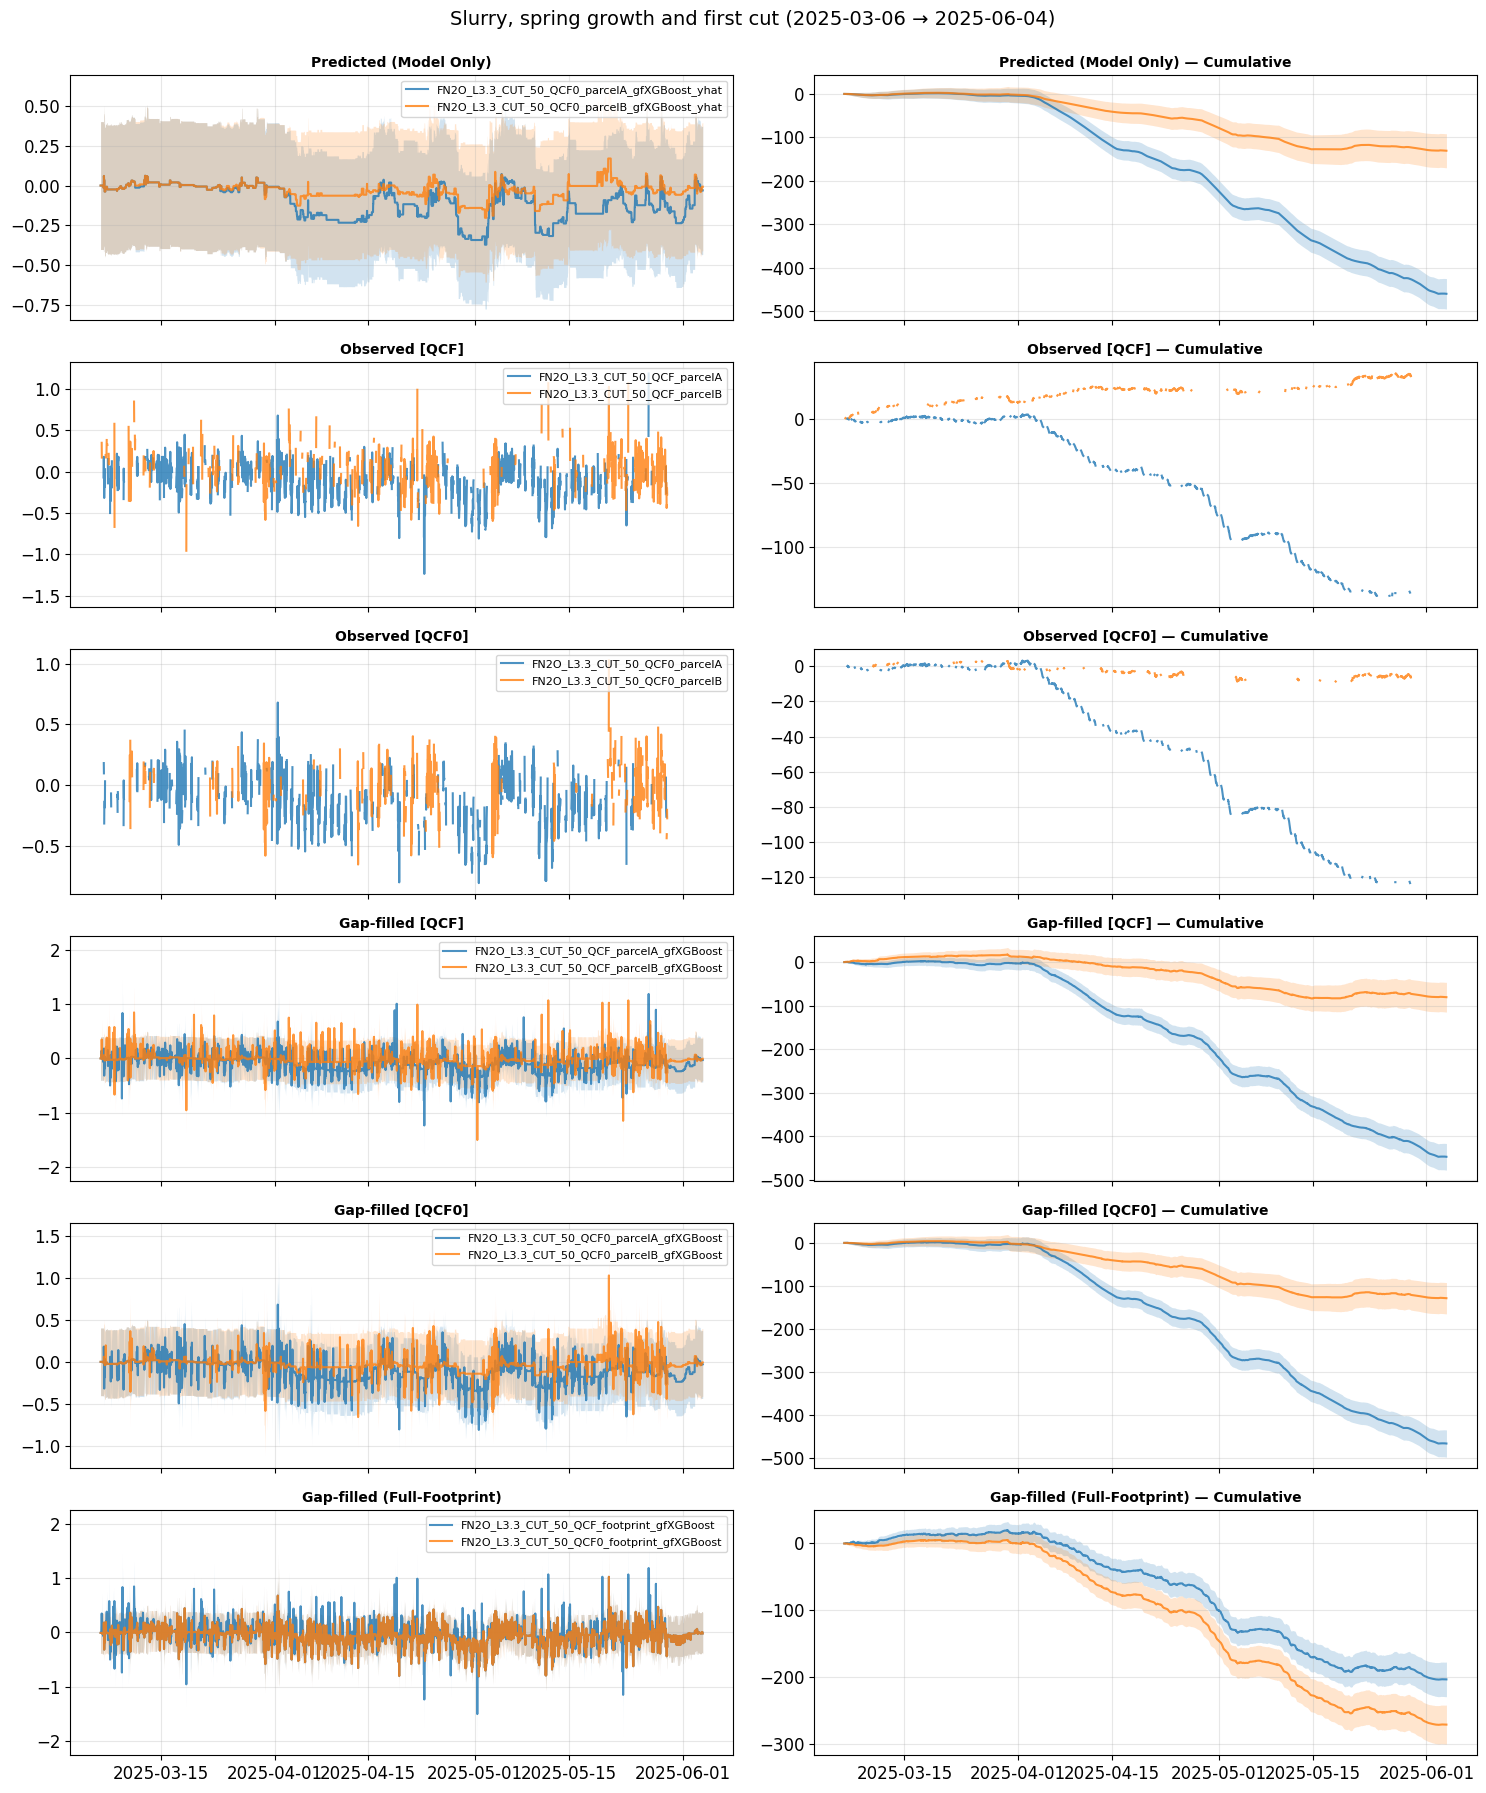

In [11]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2024-08-22", "2025-06-04", "Whole ley period"),
    ("2024-08-22", "2024-11-01", "Digestate, sowing and establishment"),
    ("2025-03-06", "2025-06-04", "Slurry, spring growth and first cut")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT50
df_CUT50 = df_final.copy()


### SHAP CHECK

 33%|=======             | 3799/11498 [00:11<00:22]       

 35%|=======             | 4042/11498 [00:12<00:22]       

 38%|========            | 4388/11498 [00:13<00:21]       

 43%|=========           | 4896/11498 [00:14<00:18]       

 47%|=========           | 5460/11498 [00:15<00:16]       

...

 77%|===============     | 8858/11498 [00:21<00:06]       

 82%|================    | 9455/11498 [00:22<00:04]       

 87%|=================   | 10043/11498 [00:23<00:03]       

 92%|==================  | 10624/11498 [00:24<00:01]       

 97%|=================== | 11184/11498 [00:25<00:00]       

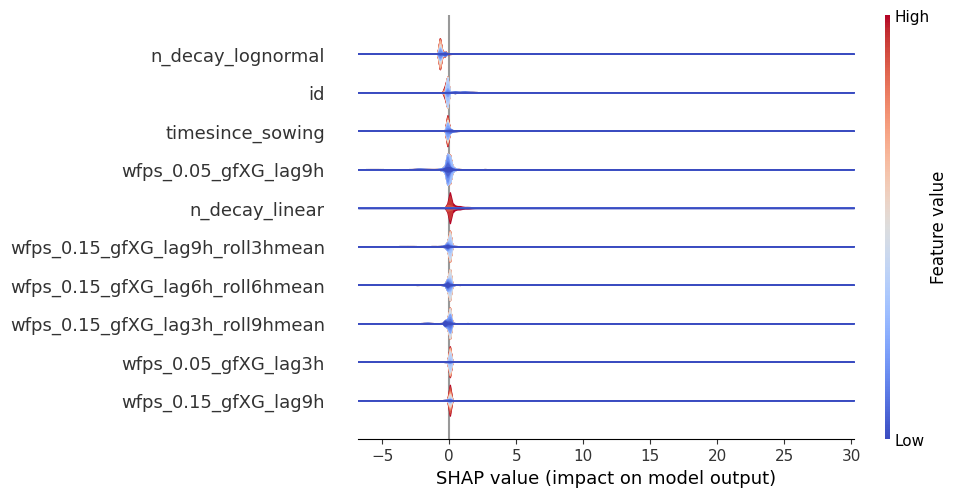

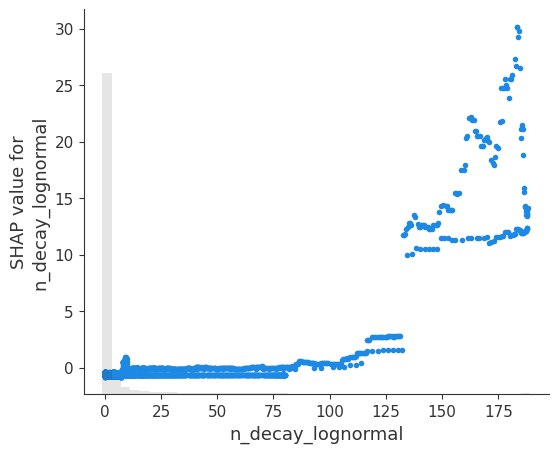

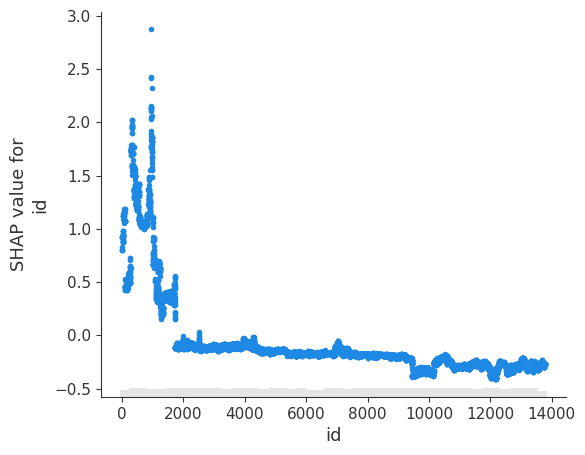

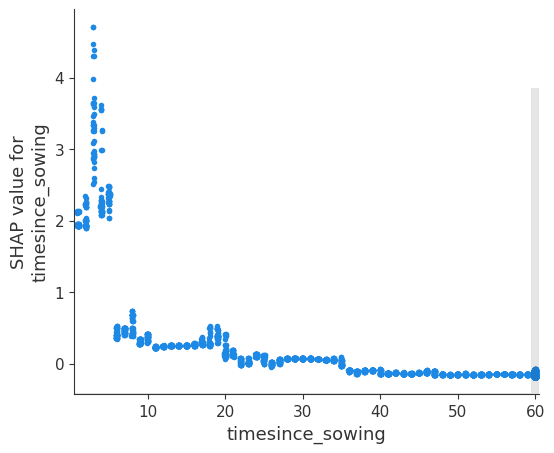

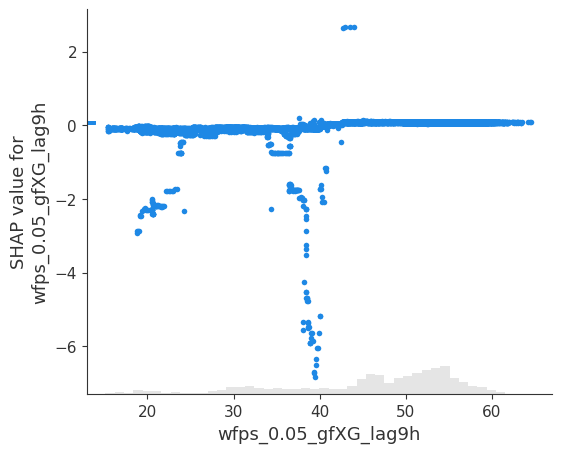

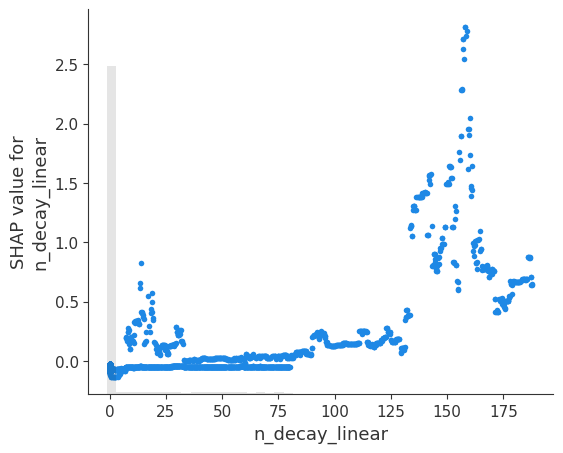

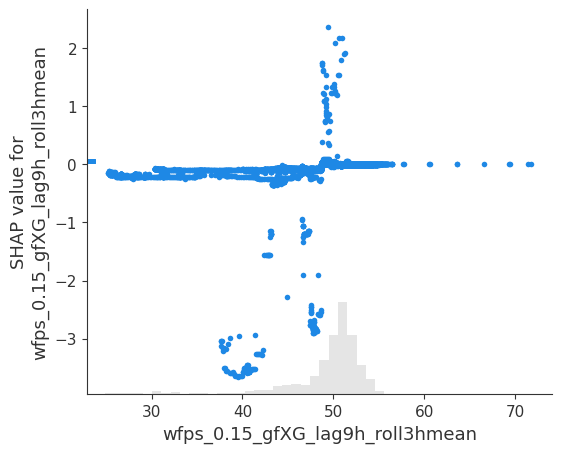

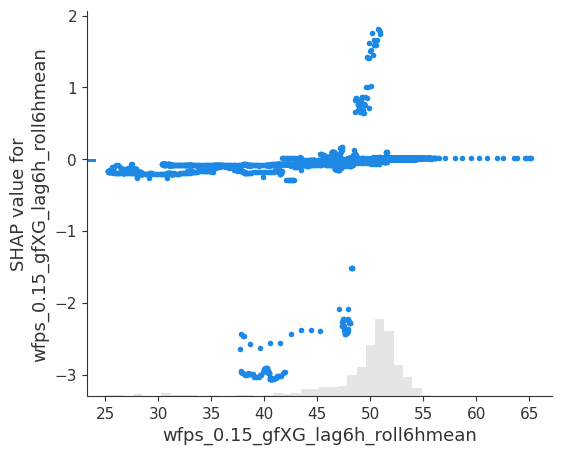

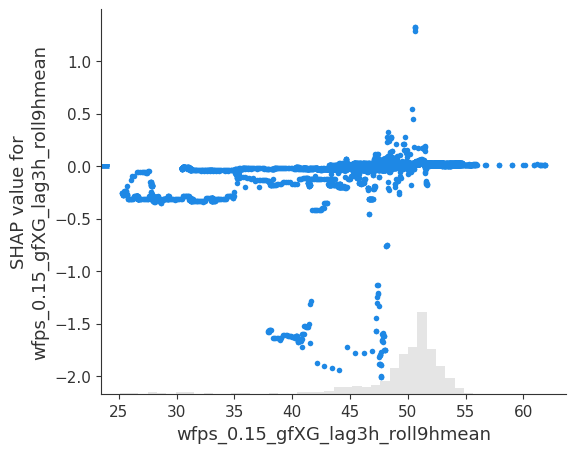

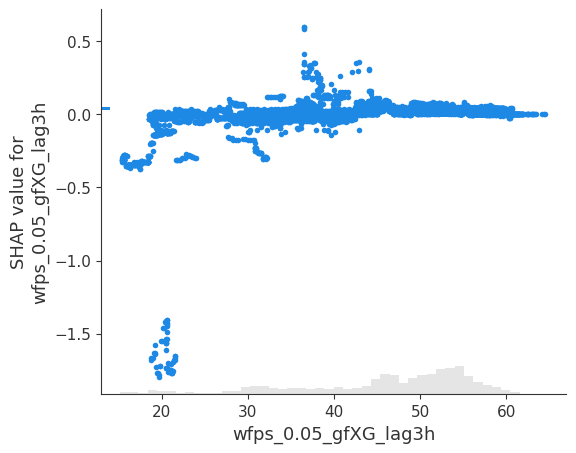

In [12]:
if SHAP_CHECK:

    # Initialize the SHAP explainer
    X = data_main[selected_features]
    explainer = shap.TreeExplainer(fit.model_final, data=X)

    # Calculate SHAP values
    shap_values = explainer(X, check_additivity=True)

    # Violin summary plot for top 10 features
    shap.plots.violin(shap_values, features=X, plot_type="layered_violin", max_display=10)
    plt.show()

    # Scatter plots of top 10 most important features
    for i in range(-1, -10, -1):
        shap.plots.scatter(shap_values[:, shap_values.abs.mean(0).argsort[i]])
        plt.show()

## CUT-84

In [13]:
USTAR_CUT = 'CUT_84'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FN2O_L3.3_CUT_84_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 17.7280; raw baseline 20.0849)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.102
  Coverage: 479/4386 rows never held out (10.9%); mean times held out 2.01


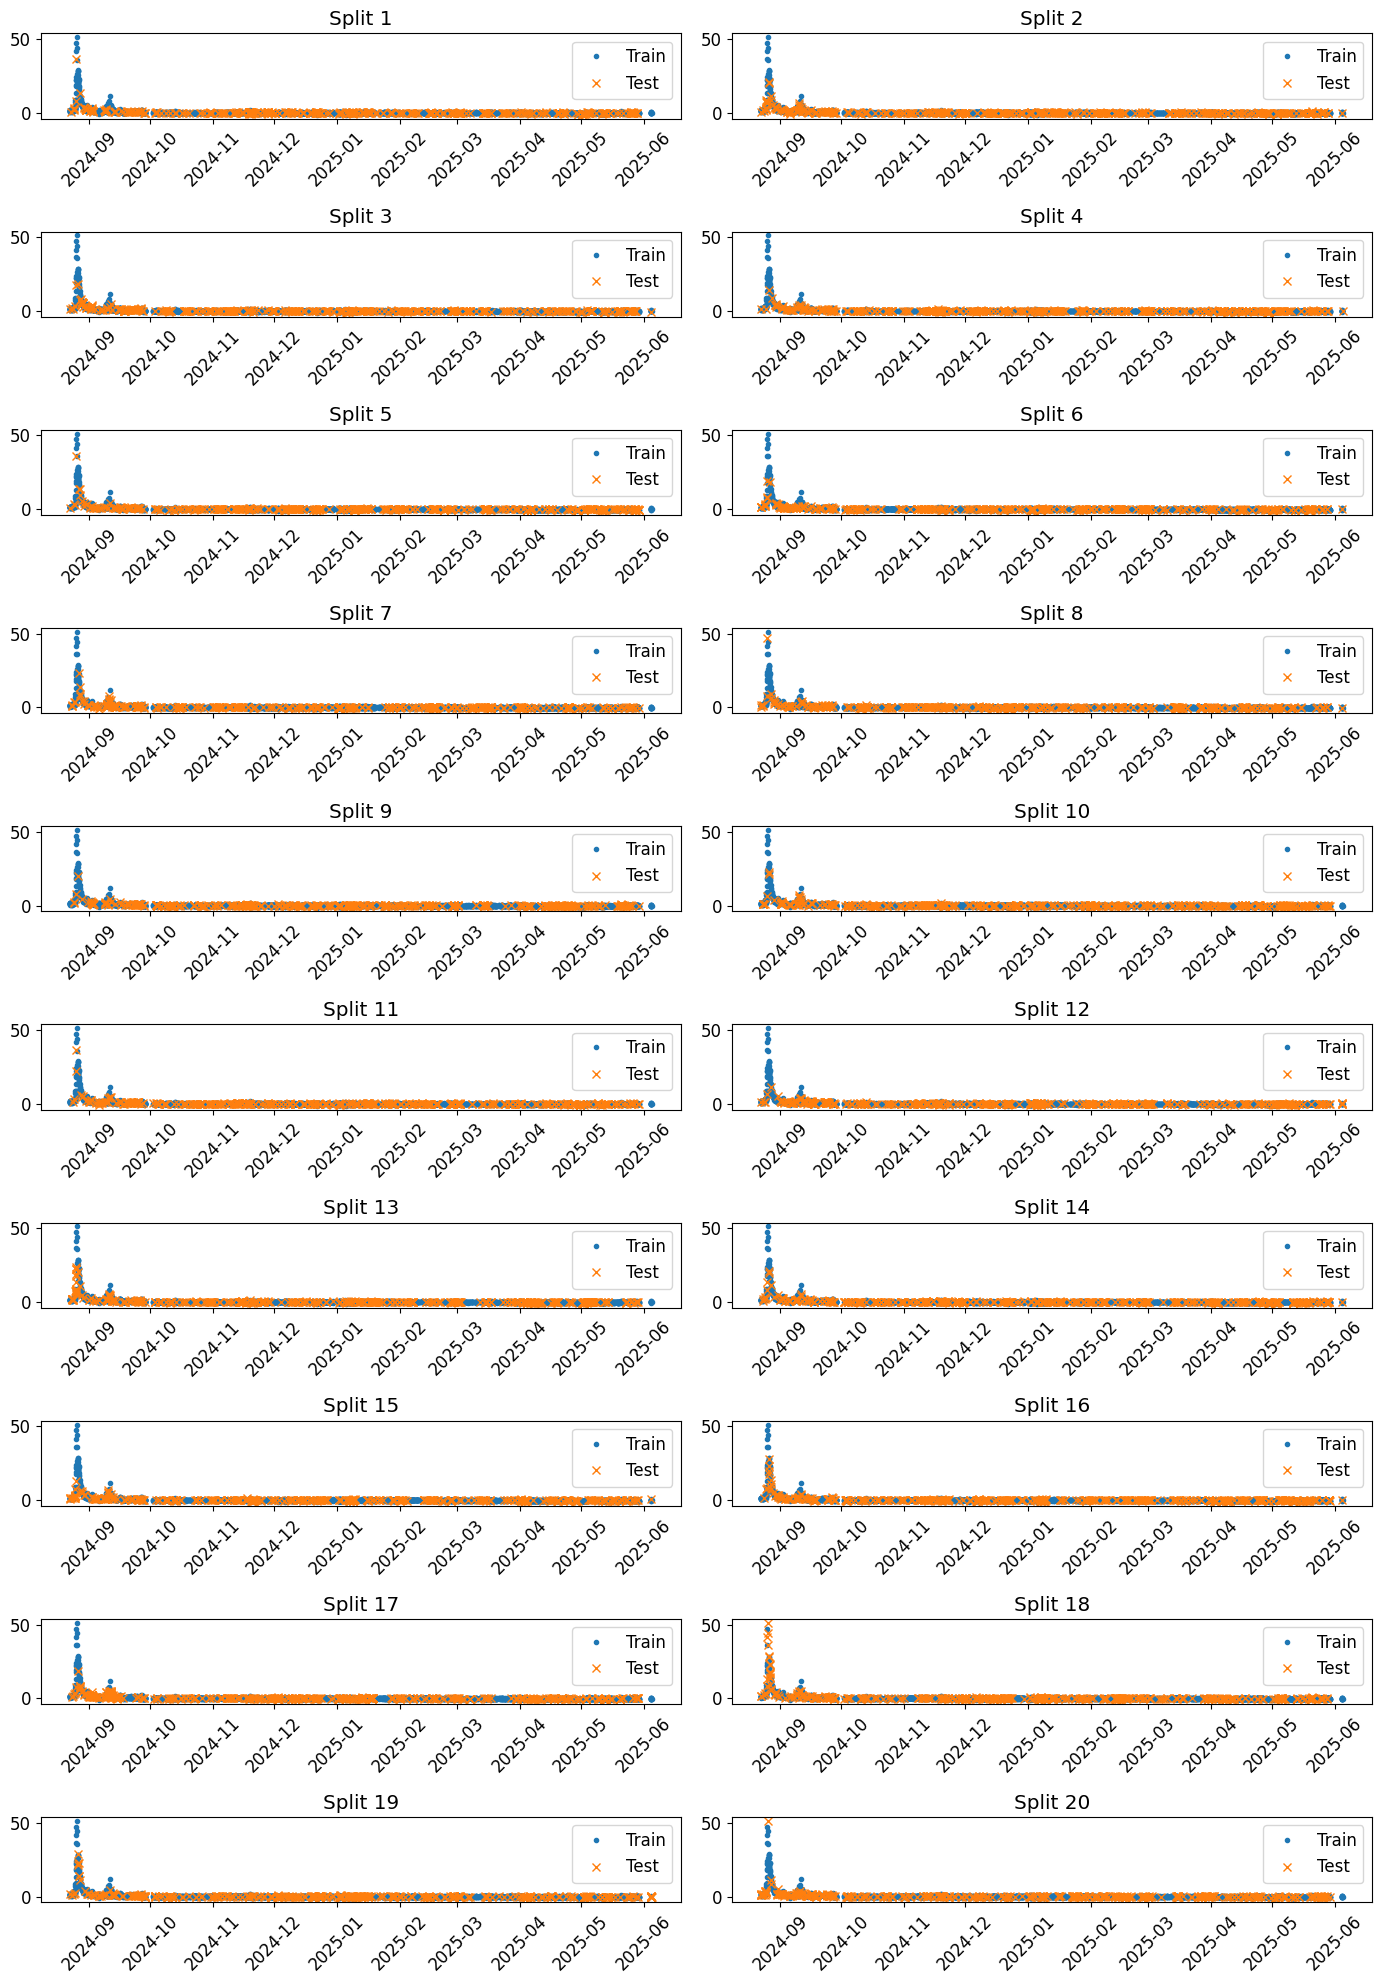

Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_84_QCF0
  RMSE:   0.5437
  MAE:    0.2342
  R2:     0.9013
----------------------------------------
Fitting final model on full training set...


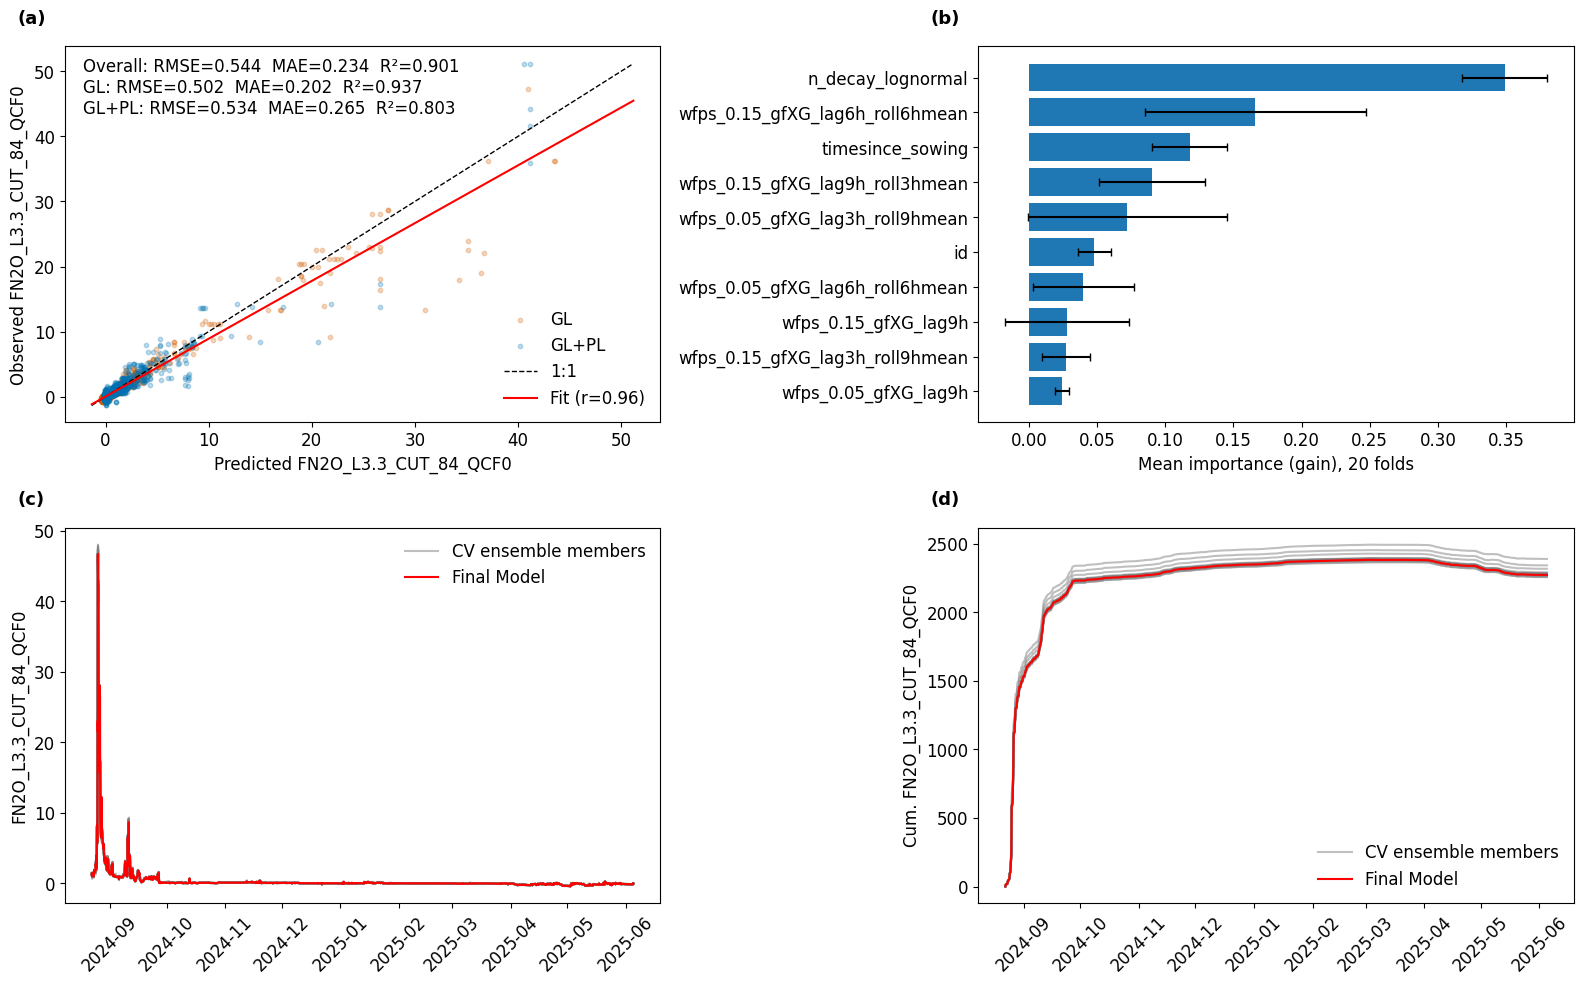

Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 21.4255; raw baseline 24.7226)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.104
  Coverage: 645/4957 rows never held out (13.0%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_84_QCF0
  RMSE:   0.5793
  MAE:    0.2395
  R2:     0.9356
----------------------------------------
Fitting final model on full training set...


Finished training. Ensemble size (folds): 20


In [14]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,
    undersample=UNDERSAMPLE,
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,
        undersample=UNDERSAMPLE,
        plot=False
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")


### GAPFILLING

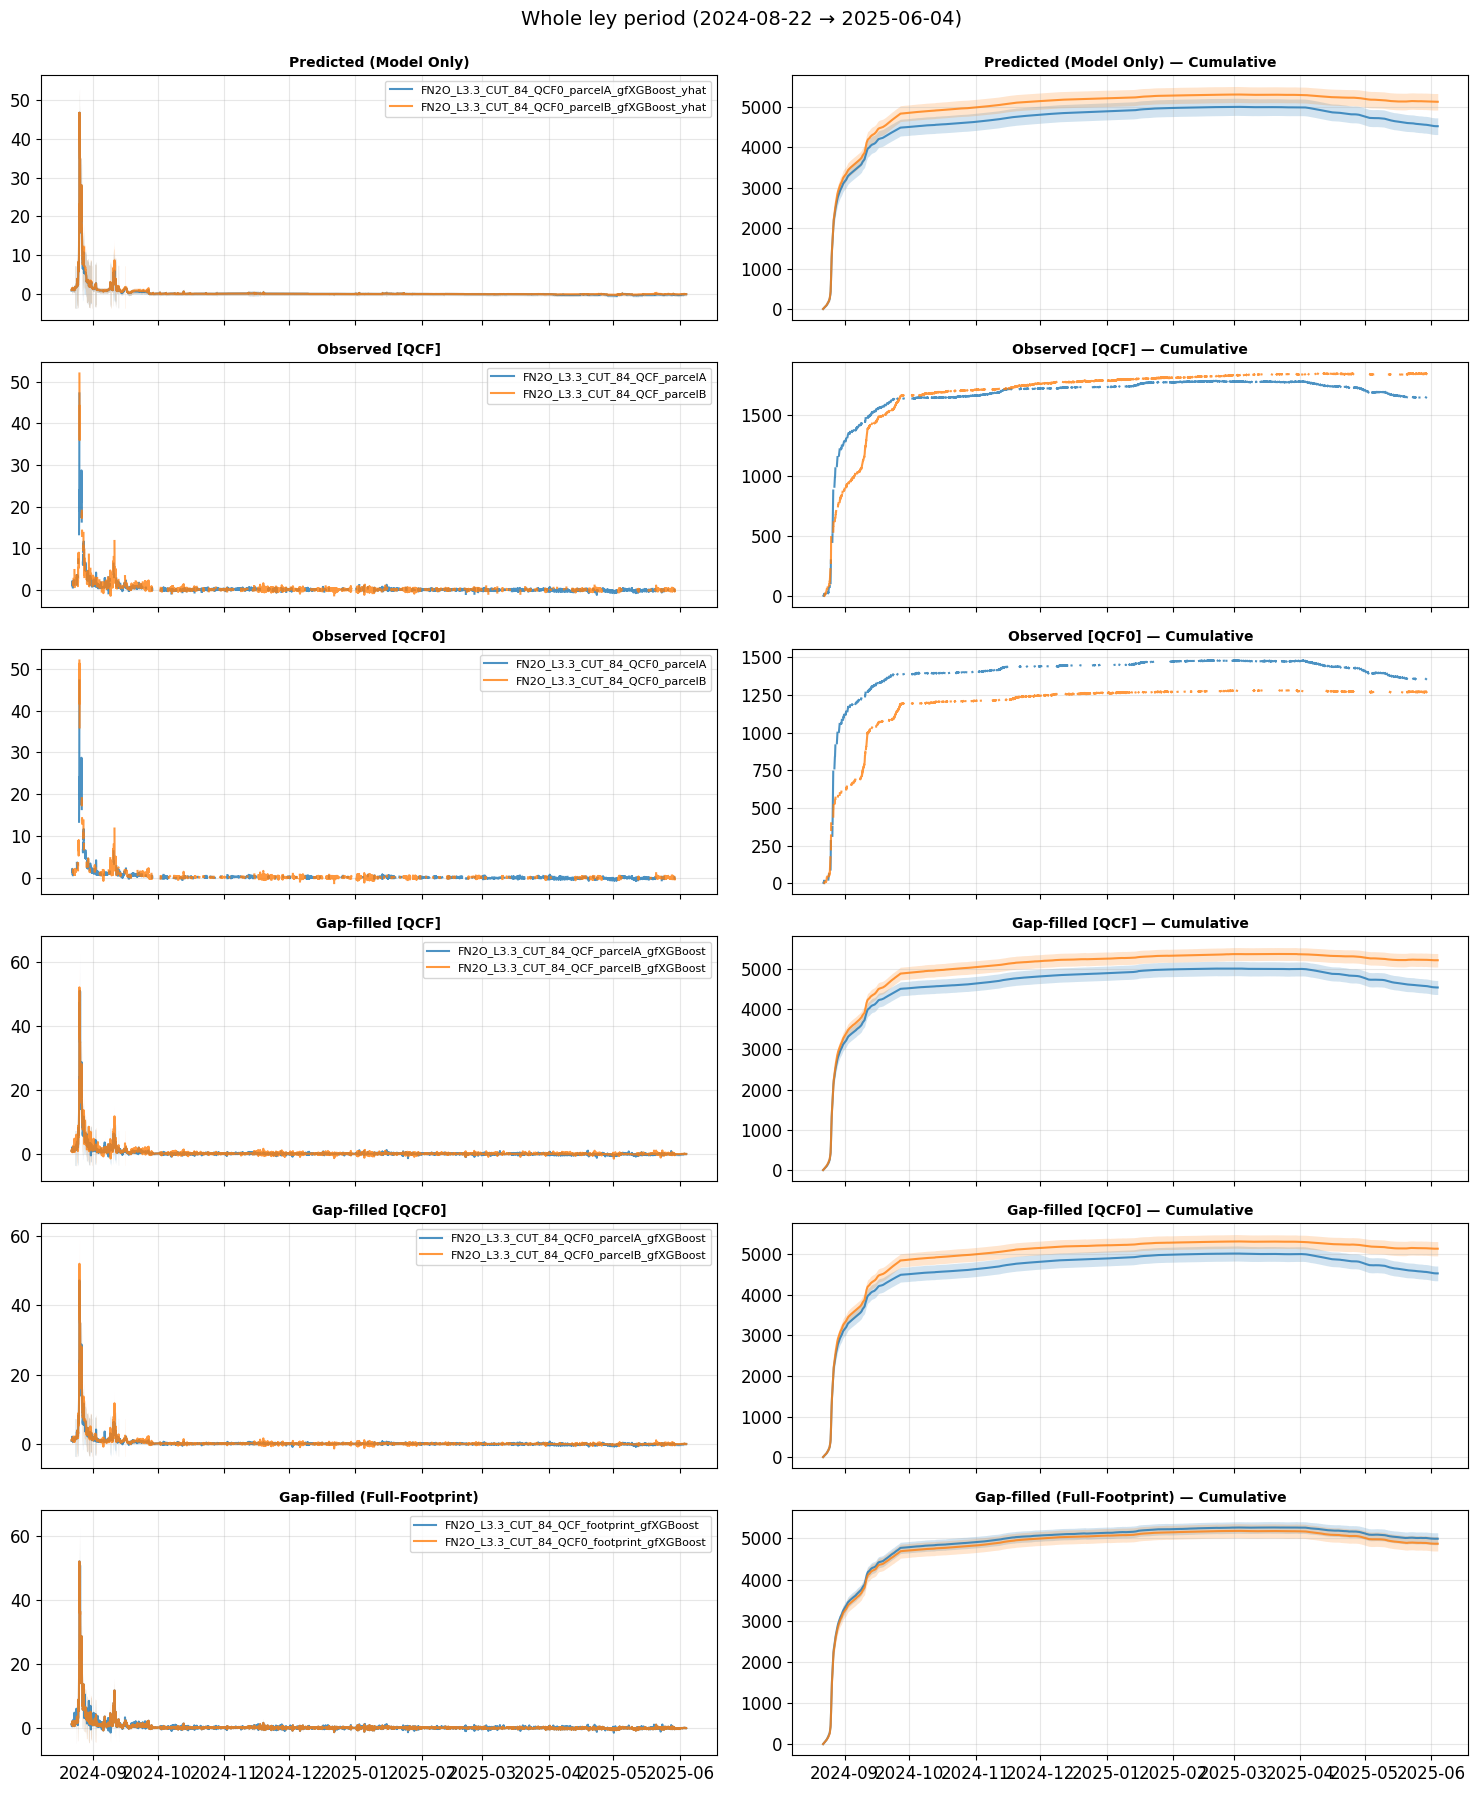

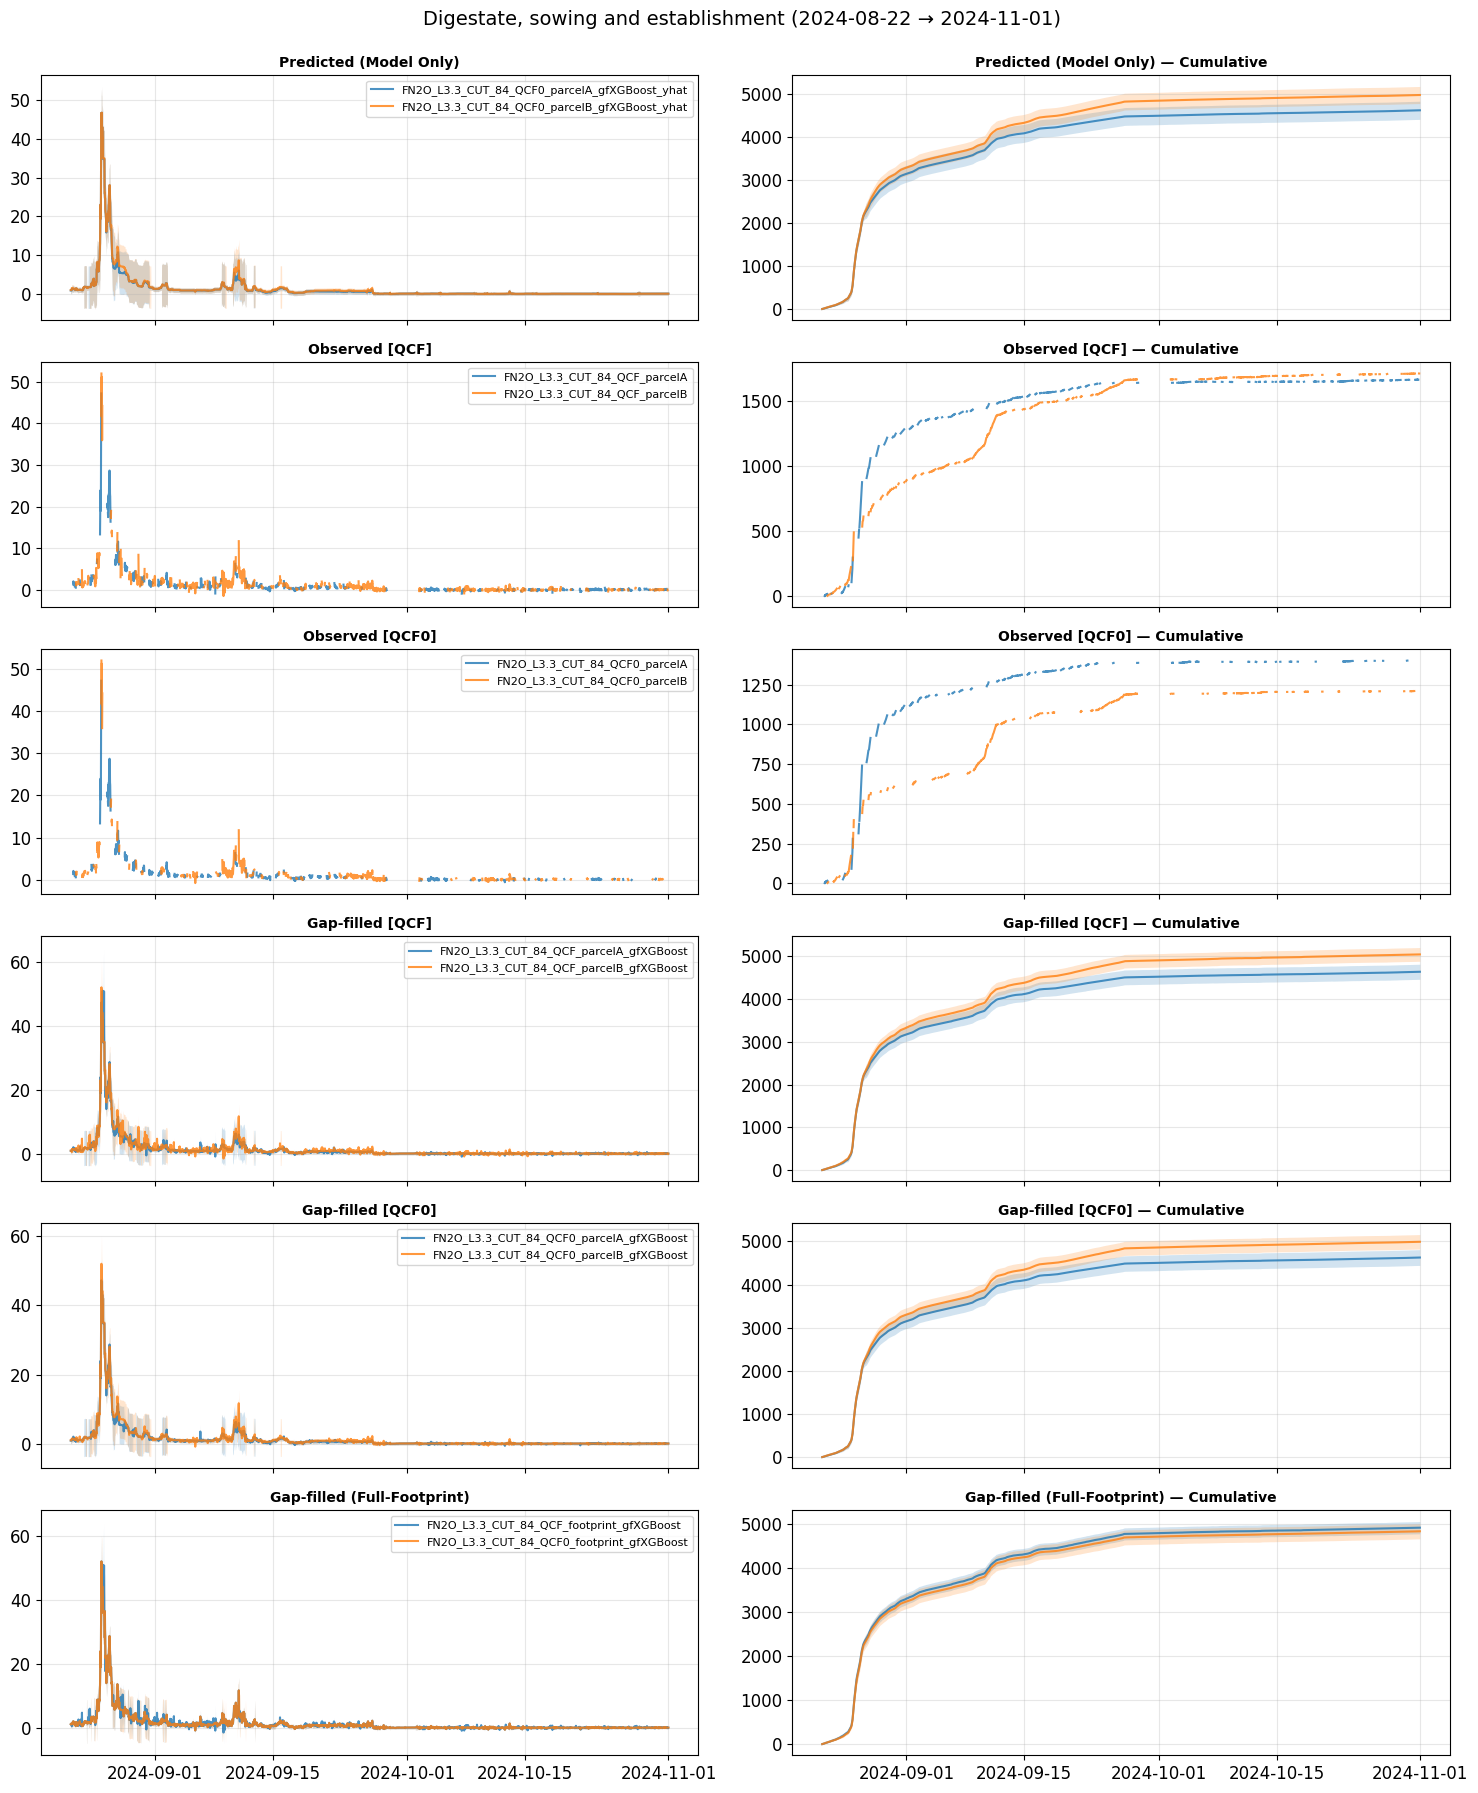

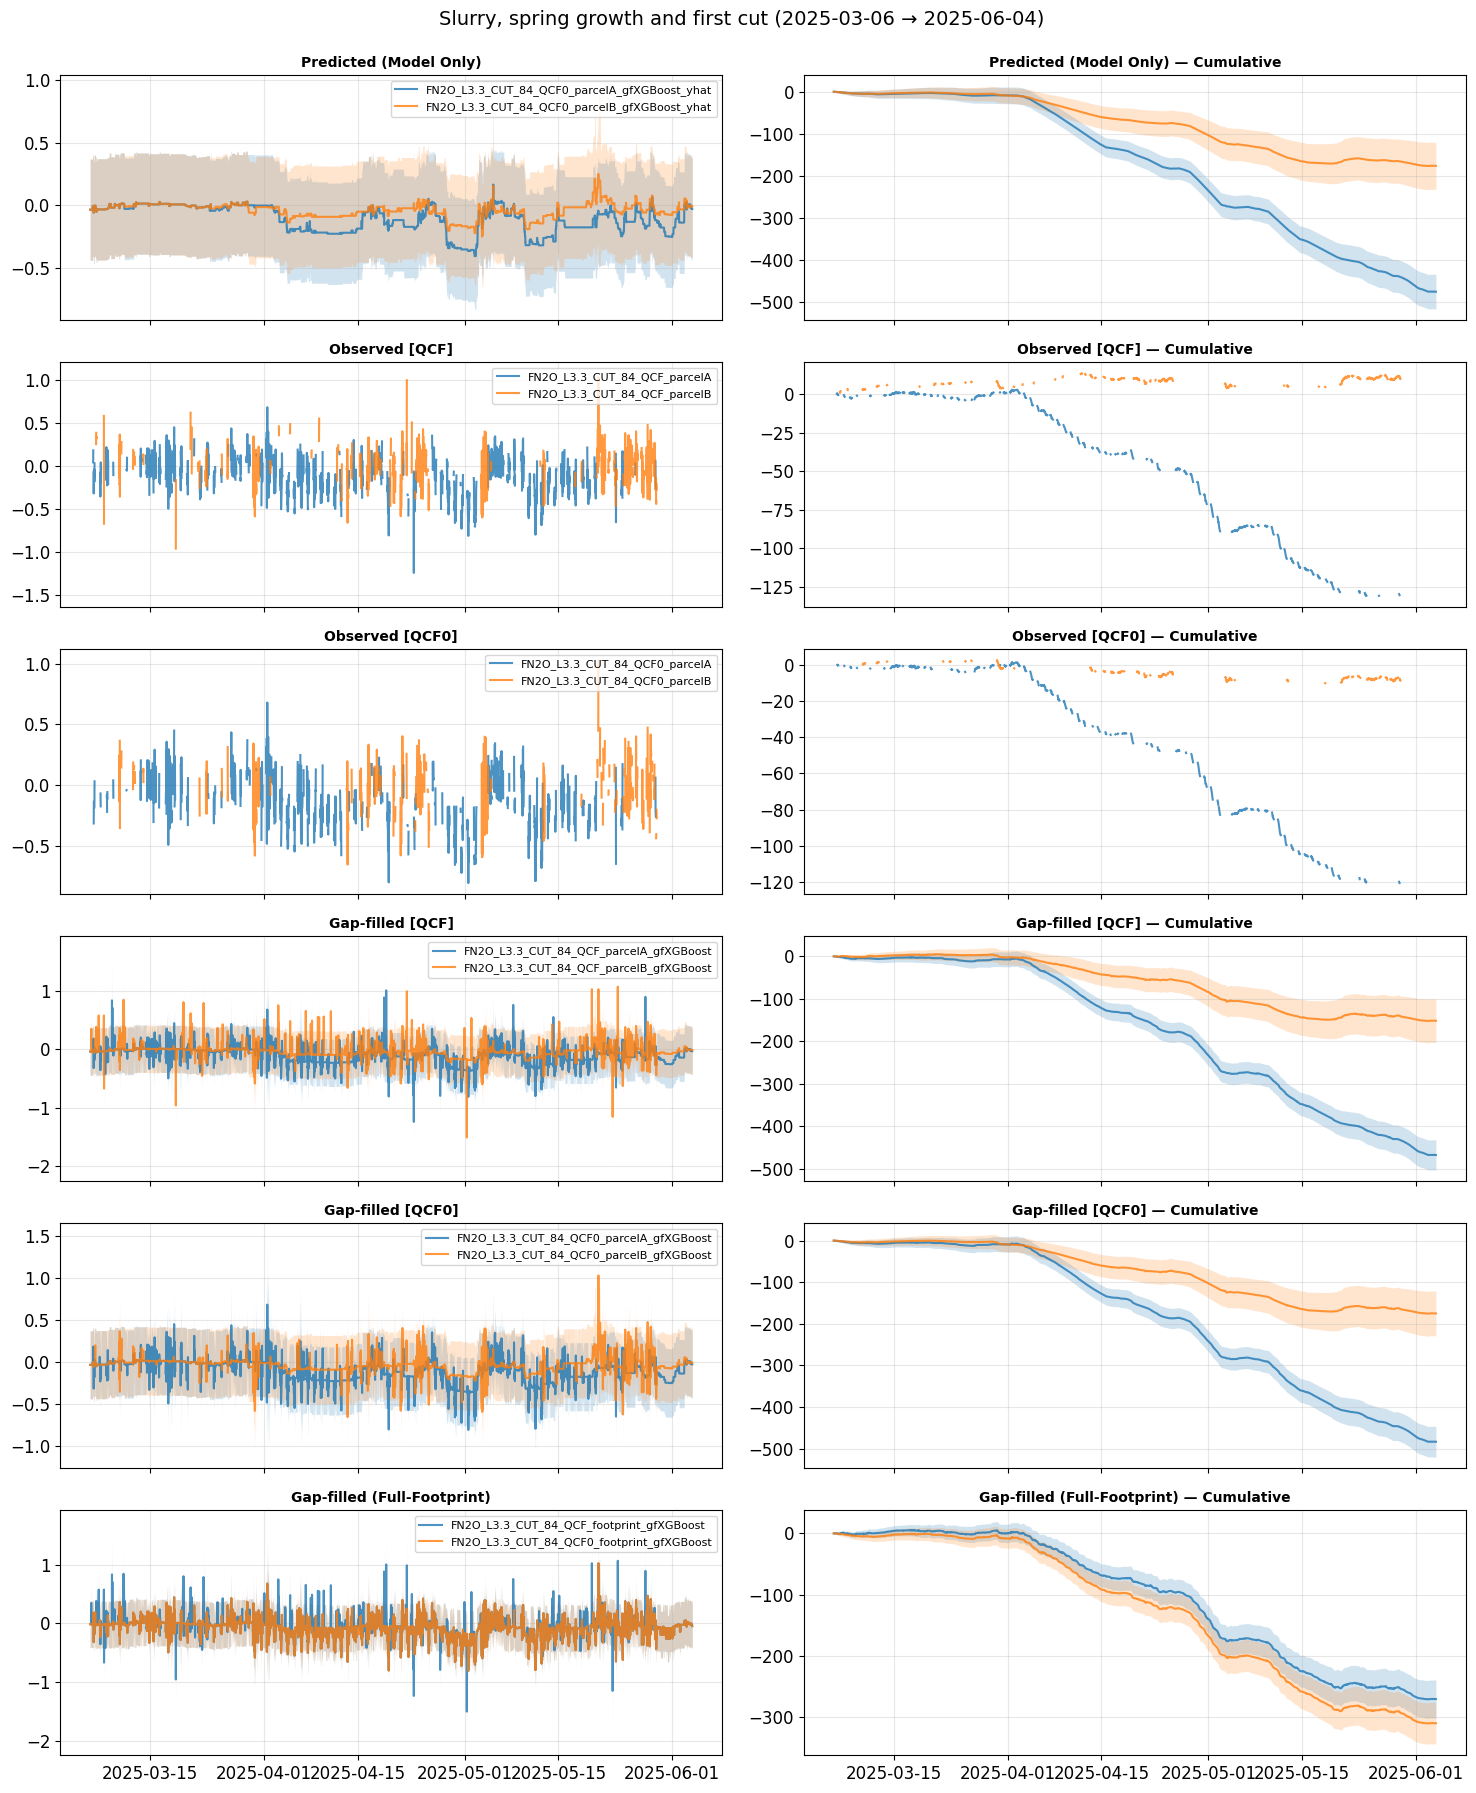

In [15]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2024-08-22", "2025-06-04", "Whole ley period"),
    ("2024-08-22", "2024-11-01", "Digestate, sowing and establishment"),
    ("2025-03-06", "2025-06-04", "Slurry, spring growth and first cut")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT84
df_CUT84 = df_final.copy()


# MERGE RESULTS

In [16]:
newcols_CUT16 = [c for c in df_CUT16.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")
display(newcols_CUT16)

newcols_CUT50 = [c for c in df_CUT50.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")  
display(newcols_CUT50)

newcols_CUT84 = [c for c in df_CUT84.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")     
display(newcols_CUT84)

# Merge the new columns into a single dataframe
gapfilled_df = pd.concat([df_CUT16[newcols_CUT16], df_CUT50[newcols_CUT50], df_CUT84[newcols_CUT84]], axis=1)

gapfilled_df

NEW VARIABLES FROM GAP-FILLING FN2O_L3.3_CUT_84_QCF0:


['FN2O_L3.3_CUT_16_QCF_parcelA',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost',
 'FLAG_FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens06',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens07',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens08',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens09',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens10',
 'FN2O_L3.3_CUT_16

NEW VARIABLES FROM GAP-FILLING FN2O_L3.3_CUT_84_QCF0:


['FN2O_L3.3_CUT_50_QCF_parcelA',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_yhat',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost',
 'FLAG_FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ISFILLED',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaGF',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaResid',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaEns',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_total_unc',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaObs',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens00',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens01',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens02',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens03',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens04',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens05',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens06',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens07',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens08',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens09',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens10',
 'FN2O_L3.3_CUT_50

NEW VARIABLES FROM GAP-FILLING FN2O_L3.3_CUT_84_QCF0:


['FN2O_L3.3_CUT_84_QCF_parcelA',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_yhat',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost',
 'FLAG_FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ISFILLED',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaGF',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaResid',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaEns',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_total_unc',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaObs',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens00',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens01',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens02',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens03',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens04',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens05',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens06',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens07',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens08',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens09',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens10',
 'FN2O_L3.3_CUT_84

,FN2O_L3.3_CUT_16_QCF_parcelA,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05,...,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens05,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens06,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens07,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens08,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens09,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens10,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens11,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens12,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens13,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens14,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens15,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens16,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens17,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens18,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens19
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,NaN,1.051834,1.051834,1,0.548847,0.436669,0.332495,0.548847,NaN,0.873462,0.787590,1.153301,2.219176,0.851467,1.019901,...,1.218148,0.811758,0.643728,1.638858,1.094947,0.922414,1.514537,1.238593,1.718593,1.284610,1.404828,0.656560,0.902941,0.915139,0.778865
2024-08-22 00:45:00,0.365031,1.051834,0.365031,0,0.548847,0.436669,0.332495,0.779504,0.779504,0.873462,0.787590,1.153301,2.219176,0.851467,1.019901,...,0.994611,0.702253,0.643728,1.588940,1.054478,0.860002,1.469090,1.067573,1.696357,1.231512,1.040785,0.505426,0.860169,0.840980,0.742225
2024-08-22 01:15:00,NaN,1.051834,1.051834,1,0.548847,0.436669,0.332495,0.548847,NaN,0.873462,0.787590,1.153301,2.219176,0.851467,1.019901,...,1.218148,0.811758,0.643728,1.638858,1.094947,0.922414,1.514537,1.238593,1.718593,1.284610,1.404828,0.656560,0.902941,0.915139,0.778865
2024-08-22 01:45:00,1.399927,1.051834,1.399927,0,0.548847,0.436669,0.332495,0.457078,0.457078,0.873462,0.787590,1.153301,2.219176,0.851467,1.019901,...,0.994611,0.702253,0.643728,1.588940,1.054478,0.860002,1.469090,1.067573,1.696357,1.231512,1.040785,0.505426,0.860169,0.840980,0.742225
2024-08-22 02:15:00,NaN,1.051834,1.051834,1,0.548847,0.436669,0.332495,0.548847,0.560318,0.873462,0.787590,1.153301,2.219176,0.851467,1.019901,...,0.994611,0.702253,0.643728,1.588940,1.054478,0.860002,1.469090,1.067573,1.696357,1.231512,1.040785,0.505426,0.860169,0.840980,0.742225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,NaN,-0.077602,-0.077602,1,0.197400,0.194840,0.031686,0.197400,NaN,-0.065363,-0.101200,-0.087228,-0.034951,-0.085925,-0.089818,...,0.007059,0.022831,0.001741,-0.003377,0.023117,0.046666,0.013219,-0.000647,0.001139,-0.025823,0.028308,-0.021451,0.014302,0.029559,0.034334
2025-06-04 22:15:00,NaN,-0.102634,-0.102634,1,0.197587,0.194840,0.032833,0.197587,NaN,-0.065363,-0.101200,-0.087228,-0.034951,-0.085925,-0.089818,...,0.007059,0.022831,0.001741,-0.003377,0.023117,0.046666,0.013219,-0.000647,0.001139,-0.025823,0.028308,-0.021451,0.014302,0.029559,0.034334
2025-06-04 22:45:00,NaN,-0.128792,-0.128792,1,0.196825,0.194840,0.027878,0.196825,NaN,-0.090182,-0.101200,-0.111851,-0.049331,-0.096956,-0.106159,...,-0.000588,0.022831,0.001741,-0.003377,0.023117,0.014717,0.013219,-0.000647,0.001139,-0.025823,0.006110,-0.021451,0.014302,0.016858,0.011253


Cumulative plots to check differences between CUT16, CUT50 and CUT84

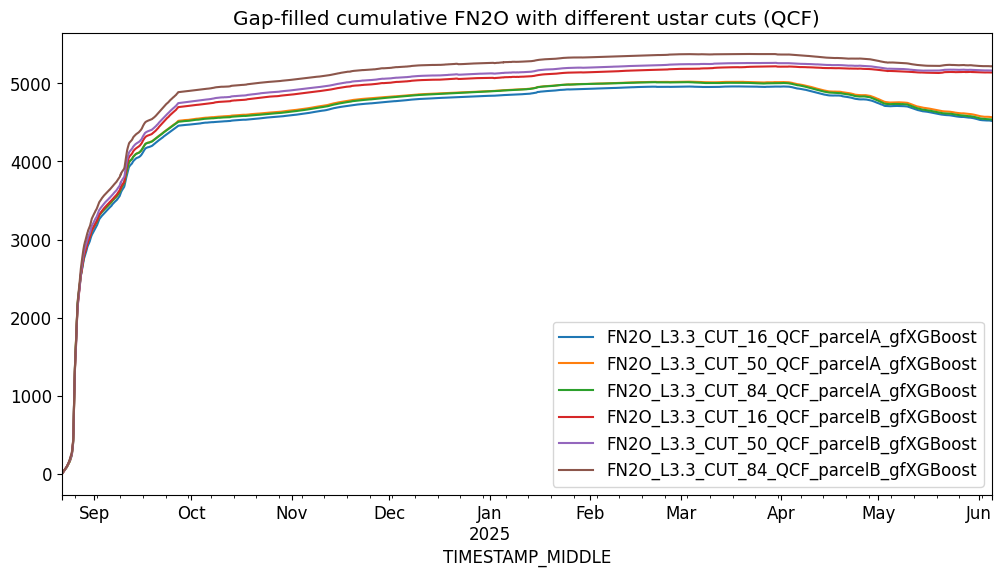

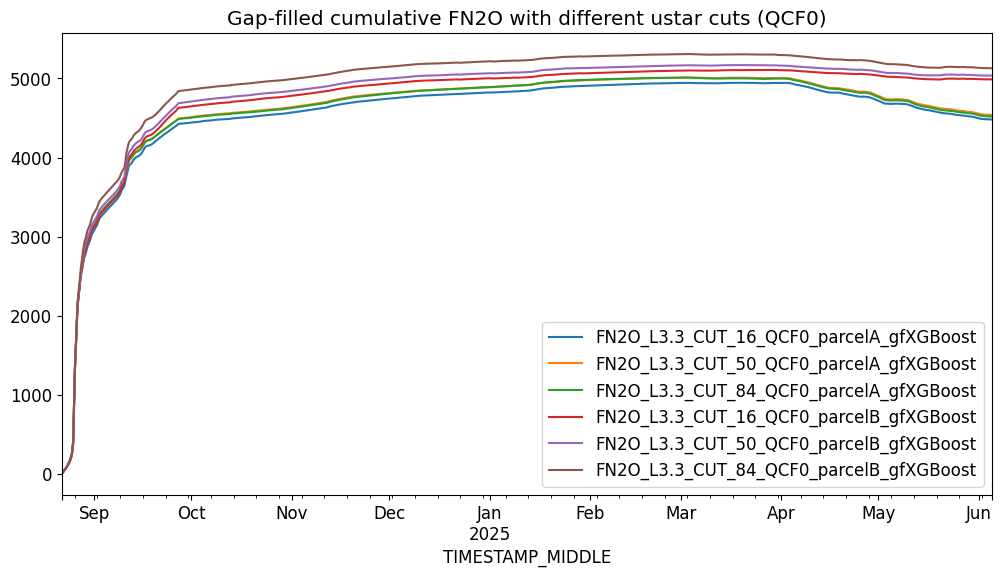

In [17]:
# Plot cumulative fluxes for different ustar cuts and QCF/QCF0
for qcf in ['QCF', 'QCF0']:
    gapfilled_df[
        [
        f'{TARGET_FLUX}_L3.3_CUT_16_{qcf}_parcelA_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_50_{qcf}_parcelA_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_84_{qcf}_parcelA_gf{MODEL_TYPE}',
        f'{TARGET_FLUX}_L3.3_CUT_16_{qcf}_parcelB_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_50_{qcf}_parcelB_gf{MODEL_TYPE}',
        f'{TARGET_FLUX}_L3.3_CUT_84_{qcf}_parcelB_gf{MODEL_TYPE}'
        ]].cumsum().plot(figsize=(12, 6), title=f'Gap-filled cumulative {TARGET_FLUX} with different ustar cuts ({qcf})')
    plt.show()

# EXPORT

In [18]:
filename = f"82.4.1_{TARGET_FLUX}_GF-{MODEL_TYPE}"
df_export = gapfilled_df.copy()
save_parquet(data=df_export, filename=filename)

Saved file 82.4.1_FN2O_GF-XGBoost.parquet (0.575 seconds).


'82.4.1_FN2O_GF-XGBoost.parquet'

# End of notebook

In [19]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-10-07 14:33:46
